# Purpose

This notebook develops and validates a **Pauli-frame-based virtual-error method** for the SecureGate project.

The objective is to study how intentionally introduced virtual Pauli errors propagate through the existing fault-tolerant logical H and S circuits and how this propagation affects the resulting syndrome information.

Workflow:

Virtual Pauli error
→ Pauli-frame propagation
→ measurement effects
→ syndrome effects

The notebook uses the exact fault-tolerant H_L and S_L circuits generated in Notebook 03 as the basis for the analysis.

The initial study considers single-qubit X, Y, and Z virtual errors and verifies their propagation before constructing a broader library of virtual-error patterns for the subsequent SecureGate mitigation experiments.

# 1. Load the Baseline Fault-Tolerant Circuits

This notebook uses the exact fault-tolerant logical H_L and S_L circuits generated in Notebook 03.

The circuits are loaded directly from their saved Stim files:

- H_L_experiment.stim
- S_L_experiment.stim

These circuits provide the fixed fault-tolerant surface-code implementations used throughout the virtual-error propagation study.

No new logical-gate construction is introduced at this stage. The purpose is to work from the same circuit implementations used in the original gate-fingerprint experiment.

In [1]:
from pathlib import Path
import stim

# Directory containing the saved Notebook 03 circuits
circuit_dir = Path(".")

# Exact baseline circuit files
h_circuit_path = circuit_dir / "H_L_experiment.stim"
s_circuit_path = circuit_dir / "S_L_experiment.stim"

# Check that the files exist
assert h_circuit_path.exists(), f"File not found: {h_circuit_path}"
assert s_circuit_path.exists(), f"File not found: {s_circuit_path}"

# Load the exact Stim circuits
h_experiment = stim.Circuit.from_file(str(h_circuit_path))
s_experiment = stim.Circuit.from_file(str(s_circuit_path))

print("Baseline circuits loaded successfully.")
print()
print("H_L circuit:")
print(f"  Qubits:       {h_experiment.num_qubits}")
print(f"  Measurements: {h_experiment.num_measurements}")
print(f"  Detectors:    {h_experiment.num_detectors}")
print(f"  Observables:  {h_experiment.num_observables}")
print()
print("S_L circuit:")
print(f"  Qubits:       {s_experiment.num_qubits}")
print(f"  Measurements: {s_experiment.num_measurements}")
print(f"  Detectors:    {s_experiment.num_detectors}")
print(f"  Observables:  {s_experiment.num_observables}")

Baseline circuits loaded successfully.

H_L circuit:
  Qubits:       81
  Measurements: 121
  Detectors:    100
  Observables:  1

S_L circuit:
  Qubits:       81
  Measurements: 121
  Detectors:    100
  Observables:  1


In [2]:
# Verify the expected baseline structure

assert h_experiment.num_qubits == 81
assert h_experiment.num_measurements == 121
assert h_experiment.num_detectors == 100

assert s_experiment.num_qubits == 81
assert s_experiment.num_measurements == 121
assert s_experiment.num_detectors == 100

print("Baseline circuit structure verified.")

Baseline circuit structure verified.


# 2. Inspect Measurements and Detectors

Before studying virtual Pauli errors, we first inspect the measurement and detector structure of the baseline fault-tolerant circuits.

Each circuit contains physical-qubit measurements that are used to construct detector events. Detector definitions reference previously recorded measurement outcomes, allowing the circuit to represent syndrome information across space and time.

This section verifies:

- the total number of measurements,
- the total number of detectors,
- the detector coordinates,
- and the measurement-record references used by the detector definitions.

The H_L and S_L circuits should have the same number of measurements and detectors, providing a common detector structure for the subsequent virtual-error propagation analysis.

In [5]:
def inspect_circuit_structure(circuit, label):
    # Print the main structural properties of the encoded circuit.
    # These values confirm that we are working with the expected
    # fault-tolerant H_L and S_L experiments from Notebook 03.
    print(f"=== {label} ===")
    print(f"Physical qubits: {circuit.num_qubits}")
    print(f"Measurements:    {circuit.num_measurements}")
    print(f"Detectors:       {circuit.num_detectors}")
    print(f"Observables:     {circuit.num_observables}")
    print()


# Inspect both baseline circuits before analyzing their detector structure.
inspect_circuit_structure(h_experiment, "H_L")
inspect_circuit_structure(s_experiment, "S_L")

=== H_L ===
Physical qubits: 81
Measurements:    121
Detectors:       100
Observables:     1

=== S_L ===
Physical qubits: 81
Measurements:    121
Detectors:       100
Observables:     1



In [6]:
# Extract the spacetime coordinates assigned to each detector.
# These coordinates allow us to identify where and when detector
# events occur in the fault-tolerant circuit.
h_detector_coords = h_experiment.get_detector_coordinates()
s_detector_coords = s_experiment.get_detector_coordinates()

# Verify that the number of detector coordinates matches the number
# of detector definitions in each circuit.
print("H_L detector coordinates:", len(h_detector_coords))
print("S_L detector coordinates:", len(s_detector_coords))

# Display a small sample of detector coordinates to inspect the
# spatial and temporal structure of the detector frame.
print("\nFirst 10 H_L detectors:")
for detector_id in sorted(h_detector_coords)[:10]:
    print(f"D{detector_id}: {h_detector_coords[detector_id]}")

print("\nFirst 10 S_L detectors:")
for detector_id in sorted(s_detector_coords)[:10]:
    print(f"D{detector_id}: {s_detector_coords[detector_id]}")

H_L detector coordinates: 100
S_L detector coordinates: 100

First 10 H_L detectors:
D0: [0.0, 1.0, 0.0]
D1: [0.0, 3.0, 0.0]
D2: [0.0, 5.0, 0.0]
D3: [0.0, 7.0, 0.0]
D4: [2.0, 1.0, 0.0]
D5: [2.0, 3.0, 0.0]
D6: [2.0, 5.0, 0.0]
D7: [2.0, 7.0, 0.0]
D8: [4.0, 1.0, 0.0]
D9: [4.0, 3.0, 0.0]

First 10 S_L detectors:
D0: [0.0, 1.0, 0.0]
D1: [0.0, 3.0, 0.0]
D2: [0.0, 5.0, 0.0]
D3: [0.0, 7.0, 0.0]
D4: [2.0, 1.0, 0.0]
D5: [2.0, 3.0, 0.0]
D6: [2.0, 5.0, 0.0]
D7: [2.0, 7.0, 0.0]
D8: [4.0, 1.0, 0.0]
D9: [4.0, 3.0, 0.0]


In [7]:
def inspect_detector_definitions(circuit, label, n=10):
    # Inspect the first few detector definitions to see which
    # measurement-record entries are combined to form each detector.
    # This is important for the later analysis of how Pauli errors
    # can propagate into changes in the measured syndrome.
    print(f"=== {label} detector definitions ===")

    detector_count = 0

    for instruction in circuit:
        # Stim stores detector definitions explicitly as DETECTOR
        # instructions within the circuit.
        if instruction.name == "DETECTOR":
            print(
                f"D{detector_count}: "
                f"coords={instruction.gate_args_copy()}, "
                f"targets={instruction.targets_copy()}"
            )

            detector_count += 1

            # Only display the first n detectors so that the output
            # remains manageable while still showing the structure.
            if detector_count >= n:
                break


# Inspect the detector construction used by each logical-gate circuit.
inspect_detector_definitions(h_experiment, "H_L")
print()
inspect_detector_definitions(s_experiment, "S_L")

=== H_L detector definitions ===
D0: coords=[0.0, 1.0, 0.0], targets=[]
D1: coords=[0.0, 3.0, 0.0], targets=[]
D2: coords=[0.0, 5.0, 0.0], targets=[]
D3: coords=[0.0, 7.0, 0.0], targets=[]
D4: coords=[2.0, 1.0, 0.0], targets=[]
D5: coords=[2.0, 3.0, 0.0], targets=[]
D6: coords=[2.0, 5.0, 0.0], targets=[]
D7: coords=[2.0, 7.0, 0.0], targets=[]
D8: coords=[4.0, 1.0, 0.0], targets=[]
D9: coords=[4.0, 3.0, 0.0], targets=[]

=== S_L detector definitions ===
D0: coords=[0.0, 1.0, 0.0], targets=[]
D1: coords=[0.0, 3.0, 0.0], targets=[]
D2: coords=[0.0, 5.0, 0.0], targets=[]
D3: coords=[0.0, 7.0, 0.0], targets=[]
D4: coords=[2.0, 1.0, 0.0], targets=[]
D5: coords=[2.0, 3.0, 0.0], targets=[]
D6: coords=[2.0, 5.0, 0.0], targets=[]
D7: coords=[2.0, 7.0, 0.0], targets=[]
D8: coords=[4.0, 1.0, 0.0], targets=[]
D9: coords=[4.0, 3.0, 0.0], targets=[]


## Understanding the Detector Output

The output above shows two pieces of information for each detector:

- `coords`: the spacetime coordinates assigned to the detector.
- `targets`: the measurement-record entries used to define the detector.

### 1. Detector coordinates

For example, the output contains:

```text
D0: coords=[0.0, 1.0, 0.0], targets=[]
D1: coords=[0.0, 3.0, 0.0], targets=[]

targets=[] means that these DETECTOR instructions contain no measurement-record references in the representation returned by this inspection.

In [8]:
# Confirm that both circuits have the expected number of measurements
# and detectors established in the Notebook 03 baseline experiment.
assert h_experiment.num_measurements == 121
assert h_experiment.num_detectors == 100

assert s_experiment.num_measurements == 121
assert s_experiment.num_detectors == 100

# Confirm that both experiments use the same detector-coordinate frame.
# This ensures that corresponding detector indices refer to the same
# spacetime locations when the two logical gates are compared.
assert h_detector_coords == s_detector_coords

print("Measurement and detector structure verified.")
print("Both circuits contain 121 measurements and 100 detectors.")
print("Detector-coordinate structures match.")

Measurement and detector structure verified.
Both circuits contain 121 measurements and 100 detectors.
Detector-coordinate structures match.


## 3. Inspecting Measurement-Record References

The previous verification confirms that both fault-tolerant circuits contain 121 measurements and 100 detectors, and that their detector-coordinate frames match.

We now inspect the actual `DETECTOR` instructions in the Stim circuit to determine how the detectors are represented and how their spacetime coordinates are defined.

In [9]:

### Code cell

def show_detector_instructions(circuit, label, n=10):
    # Convert the circuit to its Stim text representation so that we can
    # inspect the DETECTOR instructions exactly as they are encoded.
    circuit_lines = str(circuit).splitlines()

    detector_lines = [
        line.strip()
        for line in circuit_lines
        if line.strip().startswith("DETECTOR")
    ]

    print(f"=== {label} detector instructions ===")
    
    # Display only the first few detector definitions to keep the output
    # readable while exposing the measurement-record references.
    for detector_id, line in enumerate(detector_lines[:n]):
        print(f"D{detector_id}: {line}")


# Inspect the detector definitions for both logical-gate circuits.
show_detector_instructions(h_experiment, "H_L")
print()
show_detector_instructions(s_experiment, "S_L")

=== H_L detector instructions ===
D0: DETECTOR(0, 1, 0)
D1: DETECTOR(0, 3, 0)
D2: DETECTOR(0, 5, 0)
D3: DETECTOR(0, 7, 0)
D4: DETECTOR(2, 1, 0)
D5: DETECTOR(2, 3, 0)
D6: DETECTOR(2, 5, 0)
D7: DETECTOR(2, 7, 0)
D8: DETECTOR(4, 1, 0)
D9: DETECTOR(4, 3, 0)

=== S_L detector instructions ===
D0: DETECTOR(0, 1, 0)
D1: DETECTOR(0, 3, 0)
D2: DETECTOR(0, 5, 0)
D3: DETECTOR(0, 7, 0)
D4: DETECTOR(2, 1, 0)
D5: DETECTOR(2, 3, 0)
D6: DETECTOR(2, 5, 0)
D7: DETECTOR(2, 7, 0)
D8: DETECTOR(4, 1, 0)
D9: DETECTOR(4, 3, 0)


In [10]:
# Extract all detector instructions from each circuit so that we can
# verify that the number of encoded detector definitions is correct.
h_detector_lines = [
    line.strip()
    for line in str(h_experiment).splitlines()
    if line.strip().startswith("DETECTOR")
]

s_detector_lines = [
    line.strip()
    for line in str(s_experiment).splitlines()
    if line.strip().startswith("DETECTOR")
]

assert len(h_detector_lines) == 100
assert len(s_detector_lines) == 100

print("Detector instruction structure verified.")
print(f"H_L detector instructions: {len(h_detector_lines)}")
print(f"S_L detector instructions: {len(s_detector_lines)}")

Detector instruction structure verified.
H_L detector instructions: 100
S_L detector instructions: 100


## Detector Count Verification

The detector instruction count is verified for both fault-tolerant circuits:

```text
Detector instruction structure verified.
H_L detector instructions: 100
S_L detector instructions: 100

## 4. Detector Structure Across Time

The detector definitions are distributed across three spacetime layers:

- `t = 0.0`: detectors associated with the initial measurement boundary.
- `t = 1.0`: detectors associated with the intermediate syndrome-extraction stage.
- `t = 1.5`: detectors associated with the final measurement boundary.

The number of measurement-record references associated with a detector can vary between these layers.

For the H_L and S_L circuits, we therefore examine the detector structure layer by layer and count how many measurement-record references are used by each detector.

This allows us to identify how the detector record is constructed before introducing virtual Pauli errors.

In [12]:
from collections import Counter, defaultdict


def summarize_detector_structure(circuit, label):
    # Read the detector instructions directly from the Stim circuit so that
    # the analysis reflects the exact saved fault-tolerant circuit.
    detector_lines = [
        line.strip()
        for line in str(circuit).splitlines()
        if line.strip().startswith("DETECTOR")
    ]

    # Store the number of measurement-record references for each detector
    # and group the results according to the detector's time coordinate.
    target_counts_by_time = defaultdict(Counter)

    for line in detector_lines:
        # Separate the spacetime coordinates from any measurement references.
        coordinate_text, *target_text = line.split(")", 1)
        coordinate_text = coordinate_text.replace("DETECTOR(", "")

        x, y, t = [float(value.strip()) for value in coordinate_text.split(",")]

        # Count references such as rec[-20]. A detector with no references
        # will therefore have a target count of zero.
        targets = target_text[0].strip().split() if target_text else []
        target_count = len(targets)

        target_counts_by_time[t][target_count] += 1

    print(f"=== {label} detector structure ===")

    for t in sorted(target_counts_by_time):
        print(f"\nt = {t}")

        for target_count in sorted(target_counts_by_time[t]):
            number_of_detectors = target_counts_by_time[t][target_count]

            print(
                f"  {number_of_detectors} detectors use "
                f"{target_count} measurement-record reference(s)"
            )


summarize_detector_structure(h_experiment, "H_L")
print()
summarize_detector_structure(s_experiment, "S_L")

=== H_L detector structure ===

t = 0.0
  20 detectors use 0 measurement-record reference(s)
  20 detectors use 1 measurement-record reference(s)

t = 1.0
  40 detectors use 2 measurement-record reference(s)

t = 1.5
  8 detectors use 4 measurement-record reference(s)
  12 detectors use 5 measurement-record reference(s)

=== S_L detector structure ===

t = 0.0
  20 detectors use 0 measurement-record reference(s)
  20 detectors use 1 measurement-record reference(s)

t = 1.0
  20 detectors use 2 measurement-record reference(s)
  20 detectors use 3 measurement-record reference(s)

t = 1.5
  8 detectors use 4 measurement-record reference(s)
  12 detectors use 5 measurement-record reference(s)


## Interpretation

The detector structure is not identical throughout the two circuits.

At `t = 0.0`, both H_L and S_L contain:

- 20 detectors with no measurement-record references.
- 20 detectors with one measurement-record reference.

At `t = 1.0`, the structures differ:

- H_L: all 40 detectors use two measurement-record references.
- S_L: 20 detectors use two references and 20 detectors use three references.

At `t = 1.5`, both circuits contain the same distribution:

- 8 detectors use four measurement-record references.
- 12 detectors use five measurement-record references.

This difference at `t = 1.0` is part of the circuit structure that distinguishes the fault-tolerant implementations of H_L and S_L.

For the virtual-error study, this structure is important because a propagated Pauli error can change specific measurement outcomes, and those changes can subsequently affect the detector events that depend on those measurements.

In [14]:


def count_measurements_in_instruction(instruction):
    """
    Return the number of measurement results produced by a Stim instruction.
    """

    measurement_gates = {
        "M", "MX", "MY", "MZ",
        "MR", "MRX", "MRY", "MRZ",
        "MPP",
    }

    if instruction.name not in measurement_gates:
        return 0

    if instruction.name != "MPP":
        # Standard measurement instructions produce one result per qubit.
        return len(instruction.targets_copy())

    # MPP can contain several Pauli products separated by combiner targets.
    # Each product produces one measurement result.
    targets = instruction.targets_copy()

    if not targets:
        return 0

    products = 1
    for target in targets:
        if target.is_combiner:
            products += 1

    return products


def inspect_detector_measurement_references(circuit, label, max_detectors=10):
    """
    Convert the relative rec[-k] references used by DETECTOR instructions
    into absolute measurement indices.
    """

    measurement_count = 0
    detector_id = 0

    print(f"=== {label} detector measurement references ===")

    for instruction in circuit:
        # Convert the instruction into a readable representation.
        instruction_targets = instruction.targets_copy()

        if instruction.name == "DETECTOR":
            # Extract only measurement-record targets such as rec[-20].
            rec_targets = [
                target
                for target in instruction_targets
                if target.is_measurement_record_target
            ]

            # Convert each relative reference into an absolute
            # zero-based measurement index.
            absolute_indices = []

            for target in rec_targets:
                relative_index = target.value
                absolute_index = measurement_count + relative_index
                absolute_indices.append(absolute_index)

            coordinates = instruction.gate_args_copy()

            print(
                f"D{detector_id}: "
                f"coords={coordinates}, "
                f"current_measurements={measurement_count}, "
                f"absolute_measurements={absolute_indices}"
            )

            detector_id += 1

            if detector_id >= max_detectors:
                break

        else:
            # Update the number of measurements that have been recorded
            # before moving to the next circuit instruction.
            measurement_count += count_measurements_in_instruction(
                instruction
            )


inspect_detector_measurement_references(
    h_experiment,
    "H_L",
    max_detectors=60,
)

print()

inspect_detector_measurement_references(
    s_experiment,
    "S_L",
    max_detectors=60,
)

=== H_L detector measurement references ===
D0: coords=[0.0, 1.0, 0.0], current_measurements=40, absolute_measurements=[]
D1: coords=[0.0, 3.0, 0.0], current_measurements=40, absolute_measurements=[]
D2: coords=[0.0, 5.0, 0.0], current_measurements=40, absolute_measurements=[]
D3: coords=[0.0, 7.0, 0.0], current_measurements=40, absolute_measurements=[]
D4: coords=[2.0, 1.0, 0.0], current_measurements=40, absolute_measurements=[]
D5: coords=[2.0, 3.0, 0.0], current_measurements=40, absolute_measurements=[]
D6: coords=[2.0, 5.0, 0.0], current_measurements=40, absolute_measurements=[]
D7: coords=[2.0, 7.0, 0.0], current_measurements=40, absolute_measurements=[]
D8: coords=[4.0, 1.0, 0.0], current_measurements=40, absolute_measurements=[]
D9: coords=[4.0, 3.0, 0.0], current_measurements=40, absolute_measurements=[]
D10: coords=[4.0, 5.0, 0.0], current_measurements=40, absolute_measurements=[]
D11: coords=[4.0, 7.0, 0.0], current_measurements=40, absolute_measurements=[]
D12: coords=[6.0, 

## 5. Mapping Detector References to Measurement Indices

The output above maps the relative measurement-record references used by the detector definitions to absolute measurement indices.

The circuits contain 121 measurements and 100 detectors. The displayed detectors show three distinct stages in the spacetime detector structure.

### 1. Initial detector layer: `t = 0.0`

For both H_L and S_L:

The first detector group consists of detectors `D0` through `D19`.

## 6. Mapping Measurement Indices to Physical Qubits

The previous section converted the relative `rec[-k]` references into absolute measurement indices.

We now identify which physical qubit produced each measurement.

In the saved fault-tolerant H_L and S_L circuits, the 121 measurements are divided into three measurement groups:

- Measurements `0` through `39`: first measurement of the 40 ancilla qubits.
- Measurements `40` through `79`: second measurement of the same 40 ancilla qubits.
- Measurements `80` through `120`: final measurement of the 41 data qubits.

The measurement order is determined by the order of physical-qubit targets in each `M` instruction.

Therefore, the measurement record can be viewed as:

```text
measurement index
        ↓
physical qubit
        ↓
measurement group

In [16]:

import re


def build_measurement_map(circuit, label):
    # Extract the measurement instructions from the exact Stim circuit.
    # The order of qubits in each M instruction defines the corresponding
    # order of measurement indices in the global measurement record.
    measurement_map = []
    measurement_index = 0

    for line in str(circuit).splitlines():
        line = line.strip()

        if not line.startswith("M "):
            continue

        # The qubit numbers following M are measured in this exact order.
        qubits = [int(value) for value in line.split()[1:]]

        for qubit in qubits:
            measurement_map.append(
                {
                    "measurement_index": measurement_index,
                    "qubit": qubit,
                }
            )
            measurement_index += 1

    print(f"=== {label} measurement map ===")
    print(f"Total measurements: {len(measurement_map)}")

    return measurement_map


h_measurement_map = build_measurement_map(h_experiment, "H_L")
s_measurement_map = build_measurement_map(s_experiment, "S_L")

=== H_L measurement map ===
Total measurements: 121
=== S_L measurement map ===
Total measurements: 121


In [19]:
# Display the measurement groups and selected measurement-to-qubit mappings
# for both fault-tolerant logical-gate circuits.

measurement_groups = {
    "H_L": h_measurement_map,
    "S_L": s_measurement_map,
}

selected_indices = [0, 1, 19, 20, 39, 40, 59, 79, 80, 81, 120]

for label, measurement_map in measurement_groups.items():
    print(f"=== {label} measurement groups ===")
    print("Group 1: measurements 0–39")
    print("Group 2: measurements 40–79")
    print("Group 3: measurements 80–120")

    print(f"\nSelected {label} mappings:")

    for index in selected_indices:
        entry = measurement_map[index]

        print(
            f"Measurement {entry['measurement_index']:3d}"
            f" → physical qubit {entry['qubit']}"
        )

    print()

=== H_L measurement groups ===
Group 1: measurements 0–39
Group 2: measurements 40–79
Group 3: measurements 80–120

Selected H_L mappings:
Measurement   0 → physical qubit 1
Measurement   1 → physical qubit 3
Measurement  19 → physical qubit 79
Measurement  20 → physical qubit 9
Measurement  39 → physical qubit 71
Measurement  40 → physical qubit 1
Measurement  59 → physical qubit 79
Measurement  79 → physical qubit 71
Measurement  80 → physical qubit 0
Measurement  81 → physical qubit 2
Measurement 120 → physical qubit 80

=== S_L measurement groups ===
Group 1: measurements 0–39
Group 2: measurements 40–79
Group 3: measurements 80–120

Selected S_L mappings:
Measurement   0 → physical qubit 1
Measurement   1 → physical qubit 3
Measurement  19 → physical qubit 79
Measurement  20 → physical qubit 9
Measurement  39 → physical qubit 71
Measurement  40 → physical qubit 1
Measurement  59 → physical qubit 79
Measurement  79 → physical qubit 71
Measurement  80 → physical qubit 0
Measurement 

The 121 measurements in each of the H_L and S_L circuits are divided into three measurement groups.

In [20]:
# Verify the expected total number of measurements and the three
# measurement-group sizes in the saved fault-tolerant circuits.
assert len(h_measurement_map) == 121
assert len(s_measurement_map) == 121

assert [x["qubit"] for x in h_measurement_map[:40]] == \
       [x["qubit"] for x in s_measurement_map[:40]]

assert [x["qubit"] for x in h_measurement_map[40:80]] == \
       [x["qubit"] for x in s_measurement_map[40:80]]

assert [x["qubit"] for x in h_measurement_map[80:]] == \
       [x["qubit"] for x in s_measurement_map[80:]]

print("Measurement-to-qubit mapping verified.")
print("121 measurements are accounted for in both circuits.")

Measurement-to-qubit mapping verified.
121 measurements are accounted for in both circuits.


## Measurement-to-Qubit Mapping Verification

The measurement-to-qubit mapping has been verified for both fault-tolerant circuits:


Measurement-to-qubit mapping verified.
121 measurements are accounted for in both circuits.

## 7. Identifying the Logical-Gate Window

The previous sections established how detector events are connected to measurement outcomes and physical qubits.

We now identify the part of each fault-tolerant circuit that implements the logical operation.

The logical-gate window is the section between the detector layer at `t = 0.0` and the next syndrome-extraction stage.

For the two circuits, this window contains the physical operations used to realize the corresponding logical gate:

- H_L: physical H operations together with the associated SWAP structure.
- S_L: physical S and S_DAG operations together with the associated CZ structure.

Identifying this window is necessary before introducing a virtual Pauli error, because the effect of the error depends on where it is introduced relative to the physical operations implementing the logical gate.

In [21]:
def show_logical_gate_window(circuit, label):
    # Convert the saved Stim circuit into individual instructions so that
    # we can locate the physical implementation of the logical operation.
    lines = [line.strip() for line in str(circuit).splitlines()]

    # Locate the first detector instruction belonging to the initial
    # detector layer. The logical-gate window begins immediately after
    # the TICK separating this layer from the gate operation.
    first_detector = next(
        i for i, line in enumerate(lines)
        if line.startswith("DETECTOR")
    )

    # Find the TICK immediately following the initial detector definitions.
    gate_start = next(
        i for i in range(first_detector, len(lines))
        if lines[i] == "TICK"
    )

    # Find the next TICK, which marks the end of the logical-gate window.
    gate_end = next(
        i for i in range(gate_start + 1, len(lines))
        if lines[i] == "TICK"
    )

    print(f"=== {label} logical-gate window ===")

    # Display the physical operations occurring inside the logical-gate window.
    for line in lines[gate_start + 1:gate_end]:
        print(line)


show_logical_gate_window(h_experiment, "H_L")
print()
show_logical_gate_window(s_experiment, "S_L")

=== H_L logical-gate window ===
H 46 44 56 20 36 76 4 38 60 78 62 30 58 48 40 52 66 32 6 72 14 68 0 16 50 24 10 34 28 80 26 42 54 22 8 74 12 70 2 64 18
DEPOLARIZE1(0.001) 46 44 56 20 36 76 4 38 60 78 62 30 58 48 40 52 66 32 6 72 14 68 0 16 50 24 10 34 28 80 26 42 54 22 8 74 12 70 2 64 18
I 23 1 29 17 39 71 9 27 5 67 21 11 61 33 77 7 79 19 65 35 3 53 41 75 13 51 49 47 55 45 31 69 25 73 37 43 57 15 59 63
DEPOLARIZE1(0.001) 23 1 29 17 39 71 9 27 5 67 21 11 61 33 77 7 79 19 65 35 3 53 41 75 13 51 49 47 55 45 31 69 25 73 37 43 57 15 59 63

=== S_L logical-gate window ===
S 40 20 0 60 80
DEPOLARIZE1(0.001) 40 20 0 60 80
S_DAG 70 50 30 10
DEPOLARIZE1(0.001) 70 50 30 10
CZ 54 6 62 78 32 48 36 4 22 38 42 58 18 2 44 76 24 56 72 8 64 16 34 66 28 12 26 74 52 68 46 14
DEPOLARIZE2(0.001) 54 6 62 78 32 48 36 4 22 38 42 58 18 2 44 76 24 56 72 8 64 16 34 66 28 12 26 74 52 68 46 14
I 1 3 5 7 19 21 23 25 37 39 41 43 55 57 59 61 73 75 77 79 9 11 13 15 17 27 29 31 33 35 45 47 49 51 53 63 65 67 69 71
DEPOLA

## 7. Interpreting the Logical-Gate Window

The output shows the physical operations used by the saved fault-tolerant circuits to implement the logical H_L and S_L operations.

These operations are specific to the `surface-sim` unrotated surface-code construction used in Notebook 03.

### H_L physical implementation

The extracted H_L gate window contains the following operations:

    H
    DEPOLARIZE1(0.001)

    I
    DEPOLARIZE1(0.001)

The `H` operation is applied to 41 physical qubits:

    46 44 56 20 36 76 4 38 60 78 62 30 58 48 40 52 66
    32 6 72 14 68 0 16 50 24 10 34 28 80 26 42 54 22
    8 74 12 70 2 64 18

The `I` operation is applied to the remaining 40 physical qubits:

    23 1 29 17 39 71 9 27 5 67 21 11 61 33 77 7 79 19 65 35
    3 53 41 75 13 51 49 47 55 45 31 69 25 73 37 43 57 15 59 63

The `DEPOLARIZE1(0.001)` instructions represent the single-qubit noise applied after the corresponding operations.

### S_L physical implementation

The extracted S_L gate window contains:

    S
    DEPOLARIZE1(0.001)

    S_DAG
    DEPOLARIZE1(0.001)

    CZ
    DEPOLARIZE2(0.001)

    I
    DEPOLARIZE1(0.001)

The `S` operation is applied to 5 physical qubits:

    40 20 0 60 80

The `S_DAG` operation is applied to 4 physical qubits:

    70 50 30 10

The `CZ` instruction acts on pairs of physical qubits represented by the following targets:

    54 6 62 78 32 48 36 4 22 38 42 58 18 2 44 76
    24 56 72 8 64 16 34 66 28 12 26 74 52 68 46 14

The remaining 40 physical qubits receive identity operations.

The `DEPOLARIZE1(0.001)` and `DEPOLARIZE2(0.001)` instructions represent the specified single- and two-qubit noise associated with these operations.

### H_L and S_L comparison

The extracted gate windows show that H_L and S_L are implemented using different physical gate structures in the saved circuits.

    H_L → H operations + identity operations

    S_L → S/S_DAG operations + CZ operations + identity operations

This difference is important for the virtual-error analysis because the propagation of a Pauli error depends on the physical operations encountered by the affected qubit.

## 8. Pauli Propagation Rules

### Pauli Frame

A **Pauli frame** is a classical record of the Pauli corrections or errors associated with the physical qubits. Instead of physically applying a Pauli correction to the quantum state, the correction can be tracked by a classical computer and updated as the computation proceeds.

For Clifford operations, the Pauli-frame description can be updated using the corresponding Clifford–Pauli commutation rules. This allows the Pauli error to be tracked through the circuit without physically applying the correction.

In this notebook, the Pauli frame is used to track intentionally introduced virtual Pauli errors as they propagate through the fault-tolerant H_L and S_L circuits.

### Pauli Propagation

A virtual Pauli error is tracked through the fault-tolerant circuit by updating its Pauli-frame representation whenever it encounters a Clifford operation.

The relevant single-qubit propagation rules are:

**Hadamard gate**

\[
HX = ZH
\]

\[
HZ = XH
\]

**S gate**

\[
S† = Y
\]

\[
S† = Z
\]

**S† gate**

\[
S† X S = -Y
\]

\[
S† Z S = Z
\]

These relations determine how the Pauli-frame representation changes as a virtual Pauli error passes through the corresponding Clifford operation.

The Pauli error is therefore represented by its current Pauli type and physical-qubit location, which can be updated as the circuit is traversed.


In [24]:
# Represent the Pauli frame on each physical qubit using the labels:
# I, X, Y, and Z.
#
# This function updates the Pauli type on a single qubit when a
# single-qubit Clifford operation is encountered.

def propagate_single_pauli(pauli, gate):
    if gate == "H":
        mapping = {
            "I": "I",
            "X": "Z",
            "Y": "Y",
            "Z": "X",
        }
        return mapping[pauli]

    if gate == "S":
        mapping = {
            "I": "I",
            "X": "Y",
            "Y": "X",
            "Z": "Z",
        }
        return mapping[pauli]

    if gate == "S_DAG":
        mapping = {
            "I": "I",
            "X": "Y",
            "Y": "X",
            "Z": "Z",
        }
        return mapping[pauli]

    if gate in {"I", "DEPOLARIZE1"}:
        return pauli

    raise ValueError(f"Unsupported single-qubit operation: {gate}")


# Display the Pauli transformations that will be used for frame tracking.
paulis = ["I", "X", "Y", "Z"]

for gate in ["H", "S", "S_DAG"]:
    print(f"{gate}:")
    for pauli in paulis:
        print(f"  {pauli} -> {propagate_single_pauli(pauli, gate)}")
    print()

H:
  I -> I
  X -> Z
  Y -> Y
  Z -> X

S:
  I -> I
  X -> Y
  Y -> X
  Z -> Z

S_DAG:
  I -> I
  X -> Y
  Y -> X
  Z -> Z



## 9. Define the Physical-Qubit Pauli Frame

The Pauli frame is represented as a classical mapping from each physical qubit to its current Pauli operator.

For each physical qubit, the frame can contain one of four values:

- `I`: no Pauli error
- `X`: an X Pauli error
- `Y`: a Y Pauli error
- `Z`: a Z Pauli error

The frame is initialized to `I` on every physical qubit.

For the initial propagation experiment, we introduce a single virtual X error on physical qubit `0`:

    physical qubit 0 → X

All other physical qubits remain in the identity state.

This provides a controlled starting condition for tracing the virtual Pauli through the fault-tolerant circuit.

The frame will be updated as the virtual Pauli encounters the physical Clifford operations in the circuit.

In [25]:
def initialize_pauli_frame(num_qubits):
    # Start with no Pauli error recorded on any physical qubit.
    return {qubit: "I" for qubit in range(num_qubits)}


# Create an independent Pauli frame for each fault-tolerant circuit.
h_frame = initialize_pauli_frame(h_experiment.num_qubits)
s_frame = initialize_pauli_frame(s_experiment.num_qubits)

# Choose one physical data qubit for the initial propagation experiment.
# Physical qubit 0 is used as the test location in both circuits.
test_qubit = 0
initial_pauli = "X"

# Introduce the virtual Pauli error into the classical frame.
h_frame[test_qubit] = initial_pauli
s_frame[test_qubit] = initial_pauli

print("Initial H_L Pauli frame:")
print(f"  Physical qubit {test_qubit}: {h_frame[test_qubit]}")

print("\nInitial S_L Pauli frame:")
print(f"  Physical qubit {test_qubit}: {s_frame[test_qubit]}")

Initial H_L Pauli frame:
  Physical qubit 0: X

Initial S_L Pauli frame:
  Physical qubit 0: X


In [26]:
# Verify that the frame contains one intentional virtual X error
# and that all other physical qubits remain unchanged.
for frame, circuit, label in [
    (h_frame, h_experiment, "H_L"),
    (s_frame, s_experiment, "S_L"),
]:
    assert len(frame) == circuit.num_qubits
    assert frame[test_qubit] == "X"

    other_qubits = [
        qubit
        for qubit in range(circuit.num_qubits)
        if qubit != test_qubit
    ]

    assert all(frame[qubit] == "I" for qubit in other_qubits)

    print(f"{label} initial Pauli frame verified.")

H_L initial Pauli frame verified.
S_L initial Pauli frame verified.


## 10. Gate-by-Gate Pauli-Frame Propagation

We now propagate the initial virtual Pauli error through the actual fault-tolerant circuit.

The virtual error is introduced immediately after the initial `t = 0.0` detector layer and before the physical operations implementing the logical gate.

For this first test, the initial condition is:

    Physical qubit 0 → X

The Pauli frame is updated whenever the virtual Pauli encounters a Clifford operation:

- `H`
- `S`
- `S_DAG`
- `CZ`
- `SWAP`

Reset operations remove the frame information from the reset qubits, while measurement operations record whether the current Pauli frame changes the corresponding measurement outcome.

The stochastic noise instructions (`X_ERROR`, `DEPOLARIZE1`, and `DEPOLARIZE2`) are ignored during this deterministic propagation step because they represent the physical noise model rather than the intentionally introduced virtual error.

The purpose of this section is to obtain the propagated Pauli frame and the resulting measurement effects from the actual fault-tolerant circuit.

In [27]:
# Pauli operators are represented by two binary components:
#
# I = (0, 0)
# X = (1, 0)
# Z = (0, 1)
# Y = (1, 1)
#
# This representation makes the Clifford propagation rules convenient
# to implement, especially for the two-qubit CZ gate.

PAULI_TO_BITS = {
    "I": (0, 0),
    "X": (1, 0),
    "Y": (1, 1),
    "Z": (0, 1),
}

BITS_TO_PAULI = {
    (0, 0): "I",
    (1, 0): "X",
    (1, 1): "Y",
    (0, 1): "Z",
}


def initialize_frame(num_qubits):
    """Create a Pauli frame containing I on every physical qubit."""
    return {
        qubit: PAULI_TO_BITS["I"]
        for qubit in range(num_qubits)
    }


def pauli_label(bits):
    """Convert binary Pauli components back to I, X, Y, or Z."""
    return BITS_TO_PAULI[tuple(bits)]


def apply_single_qubit_clifford(frame, qubit, gate):
    """
    Update the Pauli frame under a single-qubit Clifford operation.

    The global phase of the Pauli operator is ignored because the
    present frame-tracking stage only needs the Pauli type.
    """
    x, z = frame[qubit]

    if gate == "H":
        # H exchanges X and Z components.
        frame[qubit] = (z, x)

    elif gate in {"S", "S_DAG"}:
        # Both S and S† have the same action on Pauli type
        # when the overall phase is ignored:
        # X ↔ Y and Z → Z.
        frame[qubit] = (x, z ^ x)

    elif gate == "I":
        pass

    else:
        raise ValueError(
            f"Unsupported single-qubit Clifford: {gate}"
        )


def apply_cz(frame, q1, q2):
    """
    Propagate the Pauli frame through CZ(q1, q2).

    Under CZ:
        X1 -> X1 Z2
        X2 -> Z1 X2

    Therefore, an X component on one qubit adds a Z component
    to the other qubit.
    """
    x1, z1 = frame[q1]
    x2, z2 = frame[q2]

    frame[q1] = (x1, z1 ^ x2)
    frame[q2] = (x2, z2 ^ x1)


def apply_swap(frame, q1, q2):
    """Exchange the Pauli-frame states of two physical qubits."""
    frame[q1], frame[q2] = frame[q2], frame[q1]


def active_frame(frame):
    """
    Return only the physical qubits carrying a non-identity Pauli.
    This keeps the propagation log readable.
    """
    return {
        qubit: pauli_label(bits)
        for qubit, bits in frame.items()
        if bits != PAULI_TO_BITS["I"]
    }

In [28]:
def propagate_pauli_frame(circuit, initial_qubit=0, initial_pauli="X"):
    """
    Propagate a virtual Pauli error through the fault-tolerant circuit.

    The virtual error is inserted immediately after the initial
    t = 0.0 detector layer.

    Returns:
        frame:
            Final Pauli frame on all physical qubits.

        measurement_flips:
            Mapping from absolute measurement index to the binary
            change caused by the propagated Pauli frame.

        history:
            Gate-by-gate record of changes in the non-trivial Pauli frame.
    """

    frame = initialize_frame(circuit.num_qubits)

    # Introduce the initial virtual Pauli error.
    frame[initial_qubit] = PAULI_TO_BITS[initial_pauli]

    # The first 40 detector definitions belong to the t = 0.0 layer.
    # The virtual error is inserted after this layer.
    t0_detector_count = 0
    started = False

    # Forty measurements have already been recorded before the
    # t = 0.0 detector layer in these circuits.
    measurement_index = 40

    measurement_flips = {}
    history = []

    for instruction in circuit:

        # ------------------------------------------------------------
        # Locate the point immediately after the initial t = 0.0
        # detector layer.
        # ------------------------------------------------------------
        if not started:
            if instruction.name == "DETECTOR":
                args = instruction.gate_args_copy()

                if len(args) >= 3 and args[2] == 0.0:
                    t0_detector_count += 1

                continue

            if t0_detector_count == 40 and instruction.name == "TICK":
                started = True
                continue

            continue

        name = instruction.name
        targets = instruction.targets_copy()

        before = active_frame(frame)

        # ------------------------------------------------------------
        # Single-qubit Clifford operations
        # ------------------------------------------------------------
        if name in {"H", "S", "S_DAG", "I"}:

            for target in targets:
                qubit = target.value
                apply_single_qubit_clifford(
                    frame,
                    qubit,
                    name,
                )

        # ------------------------------------------------------------
        # Two-qubit CZ operation
        # ------------------------------------------------------------
        elif name == "CZ":

            if len(targets) % 2 != 0:
                raise ValueError(
                    "CZ instruction does not contain paired targets."
                )

            for i in range(0, len(targets), 2):
                q1 = targets[i].value
                q2 = targets[i + 1].value

                apply_cz(frame, q1, q2)

        # ------------------------------------------------------------
        # Two-qubit SWAP operation
        # ------------------------------------------------------------
        elif name == "SWAP":

            if len(targets) % 2 != 0:
                raise ValueError(
                    "SWAP instruction does not contain paired targets."
                )

            for i in range(0, len(targets), 2):
                q1 = targets[i].value
                q2 = targets[i + 1].value

                apply_swap(frame, q1, q2)

        # ------------------------------------------------------------
        # Reset operations remove the Pauli-frame state on the
        # corresponding physical qubits.
        # ------------------------------------------------------------
        elif name in {"R", "RX", "RY", "RZ"}:

            for target in targets:
                frame[target.value] = PAULI_TO_BITS["I"]

        # ------------------------------------------------------------
        # Measurements:
        #
        # In a computational-basis (Z-basis) measurement, an X or Y
        # component flips the interpreted measurement bit.
        # ------------------------------------------------------------
        elif name == "M":

            for target in targets:
                qubit = target.value

                x, z = frame[qubit]

                # X or Y changes a Z-basis measurement outcome.
                measurement_flips[measurement_index] = int(x == 1)

                measurement_index += 1

        # ------------------------------------------------------------
        # Stochastic physical-noise instructions are deliberately
        # excluded from this deterministic virtual-error propagation.
        # ------------------------------------------------------------
        elif name in {
            "X_ERROR",
            "Y_ERROR",
            "Z_ERROR",
            "DEPOLARIZE1",
            "DEPOLARIZE2",
        }:
            pass

        # ------------------------------------------------------------
        # Circuit structure and detector definitions do not change
        # the Pauli frame.
        # ------------------------------------------------------------
        elif name in {
            "TICK",
            "DETECTOR",
            "OBSERVABLE_INCLUDE",
        }:
            pass

        else:
            raise ValueError(
                f"Unsupported circuit instruction encountered: {name}"
            )

        after = active_frame(frame)

        # Record only instructions that actually change the non-trivial
        # Pauli frame, keeping the propagation history readable.
        if before != after:
            history.append(
                {
                    "operation": name,
                    "before": before,
                    "after": after,
                }
            )

    if not started:
        raise RuntimeError(
            "Could not locate the end of the initial t = 0.0 detector layer."
        )

    return frame, measurement_flips, history

In [29]:
#For H_L
h_final_frame, h_measurement_flips, h_history = (
    propagate_pauli_frame(
        h_experiment,
        initial_qubit=0,
        initial_pauli="X",
    )
)

print("H_L Pauli-frame propagation completed.")
print("Final non-identity Pauli frame:")
print(active_frame(h_final_frame))

print("\nMeasurement changes:")
print({
    index: flip
    for index, flip in h_measurement_flips.items()
    if flip
})

H_L Pauli-frame propagation completed.
Final non-identity Pauli frame:
{0: 'Z', 1: 'X'}

Measurement changes:
{40: 1}


## 10. Interpreting the H_L Pauli-Frame Propagation

The initial condition for this experiment was a virtual X error on physical qubit `0`.

The propagation produced:


H_L Pauli-frame propagation completed.
Final non-identity Pauli frame:
{0: 'Z', 1: 'X'}

Measurement changes:
{40: 1}

In [30]:
#For S_L

s_final_frame, s_measurement_flips, s_history = (
    propagate_pauli_frame(
        s_experiment,
        initial_qubit=0,
        initial_pauli="X",
    )
)

print("S_L Pauli-frame propagation completed.")
print("Final non-identity Pauli frame:")
print(active_frame(s_final_frame))

print("\nMeasurement changes:")
print({
    index: flip
    for index, flip in s_measurement_flips.items()
    if flip
})

S_L Pauli-frame propagation completed.
Final non-identity Pauli frame:
{0: 'Y', 1: 'X', 9: 'X'}

Measurement changes:
{40: 1, 60: 1, 80: 1}


## 10. Interpreting the S_L Pauli-Frame Propagation

The initial condition for this experiment was a virtual X error on physical qubit `0`.

The propagation produced:

S_L Pauli-frame propagation completed.
Final non-identity Pauli frame:
{0: 'Y', 1: 'X', 9: 'X'}

Measurement changes:
{40: 1, 60: 1, 80: 1}

In [31]:
#inspect the propagation history

print("=== H_L propagation history ===")

for step, event in enumerate(h_history, start=1):
    print(f"\nStep {step}: {event['operation']}")
    print("Before:", event["before"])
    print("After: ", event["after"])


print("\n=== S_L propagation history ===")

for step, event in enumerate(s_history, start=1):
    print(f"\nStep {step}: {event['operation']}")
    print("Before:", event["before"])
    print("After: ", event["after"])

=== H_L propagation history ===

Step 1: H
Before: {0: 'X'}
After:  {0: 'Z'}

Step 2: H
Before: {0: 'Z'}
After:  {0: 'X'}

Step 3: H
Before: {0: 'X'}
After:  {0: 'Z'}

Step 4: H
Before: {0: 'Z'}
After:  {0: 'X'}

Step 5: CZ
Before: {0: 'X'}
After:  {0: 'X', 1: 'Z'}

Step 6: H
Before: {0: 'X', 1: 'Z'}
After:  {0: 'Z', 1: 'X'}

=== S_L propagation history ===

Step 1: S
Before: {0: 'X'}
After:  {0: 'Y'}

Step 2: CZ
Before: {0: 'Y'}
After:  {0: 'Y', 9: 'Z'}

Step 3: CZ
Before: {0: 'Y', 9: 'Z'}
After:  {0: 'Y', 1: 'Z', 9: 'Z'}

Step 4: H
Before: {0: 'Y', 1: 'Z', 9: 'Z'}
After:  {0: 'Y', 1: 'X', 9: 'X'}


## 11. Interpreting the Pauli-Frame Propagation History

The propagation history records how the initial virtual Pauli error changes as it passes through the Clifford operations in the fault-tolerant circuit.

For each step:

- `Before` shows the non-identity Pauli operators immediately before the operation.
- `After` shows the non-identity Pauli operators immediately after the operation.
- Only physical qubits carrying a non-identity Pauli operator are displayed.

The initial condition for both experiments is:

    Physical qubit 0 → X

---

### H_L propagation history


#### Step 1: H

Before the first Hadamard operation, the virtual Pauli error is:

    Physical qubit 0 → X

The Hadamard transformation maps X to Z:

    X → Z

Therefore, after the first H operation:

    Physical qubit 0 → Z

The frame changes from:

    {0: 'X'}

to:

    {0: 'Z'}

#### Step 2: H

The Pauli frame entering the second Hadamard is:

    Physical qubit 0 → Z

The Hadamard transformation maps Z to X:

    Z → X

Therefore:

    {0: 'Z'} → {0: 'X'}

The virtual Pauli on physical qubit 0 has returned to X.

#### Step 3: H

The frame before the third Hadamard is:

    Physical qubit 0 → X

Again, the Hadamard transformation gives:

    X → Z

Therefore:

    {0: 'X'} → {0: 'Z'}

#### Step 4: H

The frame before the fourth Hadamard is:

    Physical qubit 0 → Z

Applying H gives:

    Z → X

Therefore:

    {0: 'Z'} → {0: 'X'}

The four consecutive Hadamard transformations therefore produce the sequence:

    X → Z → X → Z → X

This follows directly from the Hadamard Pauli transformation rule.

#### Step 5: CZ

Before this CZ operation, the only non-identity Pauli is:

    Physical qubit 0 → X

The CZ operation couples physical qubits 0 and 1 at this stage of the circuit.

For a CZ operation:

    X on qubit 0 → X on qubit 0 + Z on the coupled qubit

Therefore, the X on physical qubit 0 remains X, while a Z Pauli is introduced on physical qubit 1.

The frame changes from:

    {0: 'X'}

to:

    {0: 'X', 1: 'Z'}

This is the first point at which the virtual Pauli error spreads from one physical qubit to another.

#### Step 6: H

The frame entering the final recorded Hadamard step is:

    Physical qubit 0 → X
    Physical qubit 1 → Z

The Hadamard operation transforms the two Pauli operators independently:

    X → Z
    Z → X

Therefore:

    Physical qubit 0 → Z
    Physical qubit 1 → X

The final frame becomes:

    {0: 'Z', 1: 'X'}

This agrees with the final H_L Pauli-frame result obtained previously.

---

### S_L propagation history


#### Step 1: S

The initial virtual Pauli error is:

    Physical qubit 0 → X

The S gate transforms X into Y:

    X → Y

Therefore, after the S operation:

    {0: 'X'} → {0: 'Y'}

The virtual Pauli on physical qubit 0 is now Y.

#### Step 2: CZ

Before this CZ operation:

    Physical qubit 0 → Y

A Y Pauli has an X component. Under CZ, this X component can propagate a Z Pauli to the coupled qubit.

At this step, the CZ operation couples the current Pauli on qubit 0 to physical qubit 9.

Therefore:

    Physical qubit 0 → Y
    Physical qubit 9 → Z

The frame changes from:

    {0: 'Y'}

to:

    {0: 'Y', 9: 'Z'}

The original Y on qubit 0 remains present, while a new Z appears on qubit 9.

#### Step 3: CZ

Before the second CZ step, the frame is:

    Physical qubit 0 → Y
    Physical qubit 9 → Z

The next CZ operation couples qubit 0 to physical qubit 1.

The X component of the Y on qubit 0 propagates a Z Pauli to qubit 1.

Therefore:

    Physical qubit 0 → Y
    Physical qubit 1 → Z
    Physical qubit 9 → Z

The frame changes from:

    {0: 'Y', 9: 'Z'}

to:

    {0: 'Y', 1: 'Z', 9: 'Z'}

The Z already present on qubit 9 remains unchanged.

#### Step 4: H

Before the final recorded Hadamard step:

    Physical qubit 0 → Y
    Physical qubit 1 → Z
    Physical qubit 9 → Z

The Hadamard transformation gives:

    Y → Y
    Z → X

Therefore:

    Physical qubit 0 → Y
    Physical qubit 1 → X
    Physical qubit 9 → X

The final frame becomes:

    {0: 'Y', 1: 'X', 9: 'X'}

This agrees with the final S_L Pauli-frame result obtained previously.

---

### Comparison of the two propagation histories

The same initial virtual X error on physical qubit 0 produces different propagation paths in the two fault-tolerant circuits.

For H_L:

    X → Z → X → Z → X
              ↓
             CZ
              ↓
       qubit 1 acquires Z
              ↓
             H
              ↓
       qubit 0 → Z
       qubit 1 → X

For S_L:

    X → Y
        ↓
       CZ
        ↓
    qubit 9 acquires Z
        ↓
       CZ
        ↓
    qubit 1 acquires Z
        ↓
        H
        ↓
    qubit 0 → Y
    qubit 1 → X
    qubit 9 → X

Thus, the propagation history shows explicitly how the physical Clifford structure of the H_L and S_L circuits determines the evolution and spread of the virtual Pauli frame.

## 12. From Measurement Changes to Detector Changes

The previous section determined which measurement outcomes are changed by the propagated virtual Pauli error.

We now determine which detector events are consequently affected.

A detector is defined by the parity of the measurement-record entries referenced by its `DETECTOR` instruction.

Therefore, a detector changes only when an odd number of its referenced measurements are flipped.

For example, if a detector depends on:

    measurement 40
    measurement 20

and only measurement 40 is flipped, the detector value changes.

If a detector depends on:

    measurement 40
    measurement 60

and both measurements are flipped, their effects cancel in the parity calculation and the detector value does not change.

The calculation therefore follows:

    measurement changes
            ↓
    detector measurement references
            ↓
    count flipped references
            ↓
    odd parity → detector flips
    even parity → detector unchanged

This step converts the measurement effects produced by the propagated Pauli frame into the corresponding detector changes.

In [32]:
import re


def measurement_to_detector_effects(circuit, measurement_flips):
    """
    Determine which detector values change when selected measurement
    outcomes are flipped.

    A detector changes when an odd number of its referenced measurement
    indices are flipped.
    """

    measurement_count = 0
    detector_results = []

    for line in str(circuit).splitlines():
        line = line.strip()

        if line.startswith("DETECTOR"):
            # Extract the detector's spacetime coordinates.
            coordinate_text = line.split(")", 1)[0]
            coordinate_text = coordinate_text.replace("DETECTOR(", "")
            coordinates = [
                float(value.strip())
                for value in coordinate_text.split(",")
            ]

            # Extract relative measurement-record references such as rec[-40].
            relative_refs = [
                int(value)
                for value in re.findall(
                    r"rec\[(-\d+)\]",
                    line
                )
            ]

            # Convert each relative reference into an absolute
            # measurement index using the number of measurements that
            # have already been recorded at this point.
            absolute_refs = [
                measurement_count + ref
                for ref in relative_refs
            ]

            # Count how many referenced measurements are flipped.
            flipped_references = [
                index
                for index in absolute_refs
                if measurement_flips.get(index, 0) == 1
            ]

            # Detector values are determined by parity.
            detector_flip = len(flipped_references) % 2

            detector_results.append(
                {
                    "detector": len(detector_results),
                    "coordinates": coordinates,
                    "measurement_indices": absolute_refs,
                    "flipped_measurements": flipped_references,
                    "detector_flip": detector_flip,
                }
            )

        elif line.startswith("M "):
            # Every target of a standard M instruction produces one
            # measurement result.
            measurement_count += len(line.split()) - 1

    return detector_results

In [35]:
# Determine how the measurement changes from the propagated H_L frame
# translate into changes in the detector outcomes.
h_detector_effects = measurement_to_detector_effects(
    h_experiment,
    h_measurement_flips,
)

# Perform the same measurement-to-detector analysis for the S_L circuit.
# The two circuits have different detector measurement-reference
# structures, so the mapping is evaluated independently for each one.
s_detector_effects = measurement_to_detector_effects(
    s_experiment,
    s_measurement_flips,
)

print("=== H_L detector effects ===")

# Display only detectors whose parity is changed by the virtual Pauli.
# For each such detector, show its spacetime location, the measurements
# defining it, and which of those measurements were flipped.
for result in h_detector_effects:
    if result["detector_flip"]:
        print(
            f"D{result['detector']}: "
            f"coords={result['coordinates']}, "
            f"measurements={result['measurement_indices']}, "
            f"flipped={result['flipped_measurements']}"
        )

print("\n=== S_L detector effects ===")

# Repeat the same inspection for S_L. This makes it possible to compare
# how the same initial virtual error produces detector changes under the
# two different fault-tolerant logical-gate implementations.
for result in s_detector_effects:
    if result["detector_flip"]:
        print(
            f"D{result['detector']}: "
            f"coords={result['coordinates']}, "
            f"measurements={result['measurement_indices']}, "
            f"flipped={result['flipped_measurements']}"
        )

=== H_L detector effects ===
D60: coords=[1.0, 0.0, 1.0], measurements=[40, 20], flipped=[40]

=== S_L detector effects ===
D60: coords=[1.0, 0.0, 1.0], measurements=[60, 20], flipped=[60]


## 12. Interpreting the Measurement-to-Detector Effects

The previous section identified which measurement outcomes are changed by the propagated virtual Pauli error.

We now determine which detector values change as a result.

A detector is defined by the parity of its referenced measurement outcomes. Therefore:

- If an odd number of the referenced measurements are flipped, the detector value changes.
- If an even number of the referenced measurements are flipped, the changes cancel and the detector value remains unchanged.

The calculation produced:

    === H_L detector effects ===
    D60: coords=[1.0, 0.0, 1.0], measurements=[40, 20], flipped=[40]

    === S_L detector effects ===
    D60: coords=[1.0, 0.0, 1.0], measurements=[60, 20], flipped=[60]

### H_L detector effect

For H_L, the affected detector is:

    D60

Its spacetime coordinates are:

    D60 → (x, y, t) = (1, 0, 1)

The detector is defined using two measurement indices:

    D60 → [40, 20]

From the measurement-to-qubit mapping established earlier:

    Measurement 40 → physical qubit 1
    Measurement 20 → physical qubit 9

The propagated virtual X error produced the measurement change:

    Measurement 40 → flipped

while measurement 20 was not flipped.

Therefore, among the two measurements defining D60, exactly one changes:

    [40, 20]
       ↓
    [flipped, unchanged]

The number of flipped references is therefore:

    1

Since 1 is odd, the detector parity changes.

Thus:

    H_L → D60 flips

### S_L detector effect

For S_L, the affected detector is again:

    D60

with the same spacetime coordinates:

    D60 → (x, y, t) = (1, 0, 1)

However, its measurement-reference structure is different:

    D60 → [60, 20]

From the measurement-to-qubit mapping:

    Measurement 60 → physical qubit 9
    Measurement 20 → physical qubit 9

The propagated virtual X error produced the measurement changes:

    Measurement 60 → flipped
    Measurement 20 → unchanged

Therefore:

    [60, 20]
       ↓
    [flipped, unchanged]

Again, exactly one referenced measurement is flipped.

The number of flipped references is:

    1

Since the parity is odd, D60 changes.

Thus:

    S_L → D60 flips

### Comparison of H_L and S_L

The same detector location is affected in both circuits:

    D60 → (1, 0, 1)

However, the measurements used to define that detector are different:

    H_L:
    D60 → [40, 20]

    S_L:
    D60 → [60, 20]

The corresponding flipped measurement is also different:

    H_L:
    Measurement 40 flips

    S_L:
    Measurement 60 flips

Therefore, although the detector location is the same, the measurement-reference structure through which the virtual Pauli produces the detector change differs between the two fault-tolerant circuits.

The complete propagation chain can be summarized as:

    H_L:

    virtual X on qubit 0
            ↓
    Pauli-frame propagation
            ↓
    Measurement 40 flips
            ↓
    D60 references [40, 20]
            ↓
    one referenced measurement flips
            ↓
    D60 flips


    S_L:

    virtual X on qubit 0
            ↓
    Pauli-frame propagation
            ↓
    Measurement 60 flips
            ↓
    D60 references [60, 20]
            ↓
    one referenced measurement flips
            ↓
    D60 flips

This completes the connection from the initial virtual Pauli error to the resulting detector change.

In [36]:
# Collect the detector indices whose defining measurement parity changes.
# These indices form the detector pattern produced by the propagated
# virtual Pauli error for each logical-gate circuit.
h_flipped_detectors = [
    result["detector"]
    for result in h_detector_effects
    if result["detector_flip"]
]

s_flipped_detectors = [
    result["detector"]
    for result in s_detector_effects
    if result["detector_flip"]
]

# Report the resulting detector sets so that they can be compared with
# the corresponding measurement changes derived in the previous section.
print("H_L flipped detectors:", h_flipped_detectors)
print("S_L flipped detectors:", s_flipped_detectors)

H_L flipped detectors: [60]
S_L flipped detectors: [60]


## 13. Verification of the Flipped-Detector Pattern

The verification step collects the detector indices whose defining measurement parity changes as a result of the propagated virtual Pauli error.

The output is:

    H_L flipped detectors: [60]
    S_L flipped detectors: [60]

### H_L result

The output:

    H_L flipped detectors: [60]

means that, for the H_L circuit, the virtual Pauli error changes the parity of detector `D60`, and no other detector in the circuit changes.

Therefore, the resulting detector pattern contains one flipped detector:

    D60

The corresponding detector is located at:

    D60 → (x, y, t) = (1, 0, 1)

From the previous analysis, this occurs because:

    Measurement 40 → flipped

and detector `D60` is defined by:

    D60 → [40, 20]

Only one of its two referenced measurements is flipped, so the detector parity changes.

### S_L result

The output:

    S_L flipped detectors: [60]

means that, for the S_L circuit, the virtual Pauli error also changes the parity of detector `D60`, and no other detector changes.

Therefore, the resulting detector pattern again contains one flipped detector:

    D60

The corresponding detector is located at:

    D60 → (x, y, t) = (1, 0, 1)

For S_L, the detector is defined by:

    D60 → [60, 20]

and the propagated Pauli frame causes:

    Measurement 60 → flipped

while measurement 20 remains unchanged.

Therefore, exactly one of the two referenced measurements changes, producing an odd parity change and causing `D60` to flip.

### Comparison

The final verified detector patterns are:

    H_L → [60]

    S_L → [60]

Thus, for the specific experiment considered here, the same initial virtual X error on physical qubit `0` produces a change at the same detector index in both circuits.

However, the mechanism leading to that detector change is different:

    H_L:
    Measurement 40 flips
    D60 references [40, 20]

    S_L:
    Measurement 60 flips
    D60 references [60, 20]

Therefore, the detector index alone does not fully describe the propagation. The measurement history leading to that detector change must also be considered.

This completes the verification that the propagated virtual Pauli error has been converted into a well-defined detector pattern for both fault-tolerant logical-gate circuits.

## 14. Constructing the Virtual-Error Detector Mask

The previous section verified which detector indices are affected by the propagated virtual Pauli error.

For the current test, the flipped-detector patterns are:

    H_L → [60]

    S_L → [60]

We now represent each result as a binary detector mask containing one entry for each of the 100 detectors.

The mask uses the following convention:

    0 → detector unchanged
    1 → detector flipped

Therefore, for the present experiment, the mask contains a `1` at detector index `60` and `0` at all other detector indices.

This provides a compact representation of the detector changes produced by the specific virtual Pauli error studied in this notebook.

The same representation will later be used to store the masks generated for different physical qubits and different Pauli errors.

In [38]:
import numpy as np

def build_detector_mask(detector_effects, num_detectors):
    # Create a binary mask with one entry for each detector.
    # A value of 1 indicates that the detector changes under the
    # propagated virtual Pauli error.
    mask = np.zeros(num_detectors, dtype=np.uint8)

    # Mark every detector whose measurement-reference parity changes.
    for result in detector_effects:
        if result["detector_flip"]:
            mask[result["detector"]] = 1

    return mask


# Construct the 100-detector masks for the current H_L and S_L tests.
h_virtual_mask = build_detector_mask(
    h_detector_effects,
    h_experiment.num_detectors,
)

s_virtual_mask = build_detector_mask(
    s_detector_effects,
    s_experiment.num_detectors,
)

print("H_L virtual-error detector mask:")
print(h_virtual_mask)

print("\nS_L virtual-error detector mask:")
print(s_virtual_mask)

H_L virtual-error detector mask:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

S_L virtual-error detector mask:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### Meaning of the Detector Mask

The detector mask is a binary representation of the change produced by the propagated virtual Pauli error across the complete detector record.

For a circuit with 100 detectors, the mask contains 100 binary entries:

    mask[j] = 0 → detector j is unchanged
    mask[j] = 1 → detector j is flipped

Thus, the mask does not represent the original detector record. Instead, it represents the **change introduced by the propagated virtual error**.

For example:

    H_L virtual-error detector mask:
    [0 0 0 ... 0 1 0 ... 0]

contains a `1` at index `60`. Therefore:

    mask[60] = 1

which means that detector `D60` changes because of the virtual error.

All other entries are `0`:

    mask[j] = 0    for j ≠ 60

meaning that those detectors are unchanged.

The same interpretation applies to the S_L mask.

In this experiment:

    H_L mask → D60 changes
    S_L mask → D60 changes

Therefore, each mask contains the complete set of detector changes produced by the specific virtual X error on physical qubit `0`.

The mask can be thought of as a **change pattern**:

    Virtual Pauli error
            ↓
    Pauli-frame propagation
            ↓
    Changed measurements
            ↓
    Changed detector parities
            ↓
    Binary detector mask

For the current experiment, the resulting mask contains one changed detector and 99 unchanged detectors.

This mask will later provide the representation of the virtual-error effect that can be associated with different physical qubits and Pauli types.

In [39]:
# The current virtual X error should affect only detector 60.
assert np.flatnonzero(h_virtual_mask).tolist() == [60]
assert np.flatnonzero(s_virtual_mask).tolist() == [60]

# Each mask must contain exactly 100 detector entries.
assert len(h_virtual_mask) == 100
assert len(s_virtual_mask) == 100

print("Virtual-error detector masks verified.")
print("H_L nonzero mask indices:", np.flatnonzero(h_virtual_mask).tolist())
print("S_L nonzero mask indices:", np.flatnonzero(s_virtual_mask).tolist())

Virtual-error detector masks verified.
H_L nonzero mask indices: [60]
S_L nonzero mask indices: [60]


## 14. Verification of the Virtual-Error Detector Masks

The detector masks have been successfully verified.

The nonzero mask indices are:

    H_L → [60]
    S_L → [60]

Thus, for the current virtual X error on physical qubit `0`, both circuits produce a detector mask in which only detector `D60` is affected.

## 15. Validate Virtual Y and Z Errors

The previous section validated a virtual \(X\) error on physical qubit 0.

Here, we repeat the same analysis for virtual \(Y\) and \(Z\) errors on the same physical qubit. The purpose is to verify that the Pauli-frame propagation rules correctly handle all three single-qubit Pauli types before generalizing the method to the full data-qubit set.

For each initial Pauli error, we track:

\[
\text{initial Pauli}
\rightarrow
\text{Pauli-frame propagation}
\rightarrow
\text{measurement changes}
\rightarrow
\text{detector changes}.
\]

The resulting detector patterns will later be used as the virtual-error masks in the mitigation experiment.

In [42]:
# Load the exact fault-tolerant H_L and S_L circuits used in the experiment.
# These circuit files are the same circuits used for the detector analysis.

import stim

with open("H_L_experiment.stim", "r") as f:
    H_circuit = stim.Circuit(f.read())

with open("S_L_experiment.stim", "r") as f:
    S_circuit = stim.Circuit(f.read())

print("H_L circuit loaded.")
print("S_L circuit loaded.")

print(f"H_L: {H_circuit.num_detectors} detectors, "
      f"{H_circuit.num_observables} observable(s)")

print(f"S_L: {S_circuit.num_detectors} detectors, "
      f"{S_circuit.num_observables} observable(s)")

H_L circuit loaded.
S_L circuit loaded.
H_L: 100 detectors, 1 observable(s)
S_L: 100 detectors, 1 observable(s)


In [47]:
import inspect

print(inspect.signature(propagate_pauli_frame))

(circuit, initial_qubit=0, initial_pauli='X')


In [48]:
# Validate virtual Y and Z errors on physical qubit 0.
# The existing Pauli-frame propagation function is used with the
# Pauli type changed from X to Y and Z.

test_paulis = ["Y", "Z"]

for pauli in test_paulis:
    print("=" * 70)
    print(f"Virtual {pauli} error on physical qubit 0")
    print("=" * 70)

    # Propagate the selected Pauli through the exact logical H circuit.
    h_result = propagate_pauli_frame(
        H_circuit,
        initial_qubit=0,
        initial_pauli=pauli
    )

    # Propagate the selected Pauli through the exact logical S circuit.
    s_result = propagate_pauli_frame(
        S_circuit,
        initial_qubit=0,
        initial_pauli=pauli
    )

Virtual Y error on physical qubit 0
Virtual Z error on physical qubit 0


In [49]:
# Inspect the propagation results for virtual Y and Z errors.
# This lets us verify the final Pauli frame and measurement changes
# produced by the existing propagation implementation.

for pauli in ["Y", "Z"]:
    print("=" * 70)
    print(f"Virtual {pauli} error on physical qubit 0")
    print("=" * 70)

    result = propagate_pauli_frame(
        H_circuit,
        initial_qubit=0,
        initial_pauli=pauli
    )

    print("Result type:", type(result))
    print("Result:")
    print(result)

Virtual Y error on physical qubit 0
Result type: <class 'tuple'>
Result:
({0: (1, 1), 1: (1, 0), 2: (0, 0), 3: (0, 0), 4: (0, 0), 5: (0, 0), 6: (0, 0), 7: (0, 0), 8: (0, 0), 9: (1, 0), 10: (0, 0), 11: (0, 0), 12: (0, 0), 13: (0, 0), 14: (0, 0), 15: (0, 0), 16: (0, 0), 17: (0, 0), 18: (0, 0), 19: (0, 0), 20: (0, 0), 21: (0, 0), 22: (0, 0), 23: (0, 0), 24: (0, 0), 25: (0, 0), 26: (0, 0), 27: (0, 0), 28: (0, 0), 29: (0, 0), 30: (0, 0), 31: (0, 0), 32: (0, 0), 33: (0, 0), 34: (0, 0), 35: (0, 0), 36: (0, 0), 37: (0, 0), 38: (0, 0), 39: (0, 0), 40: (0, 0), 41: (0, 0), 42: (0, 0), 43: (0, 0), 44: (0, 0), 45: (0, 0), 46: (0, 0), 47: (0, 0), 48: (0, 0), 49: (0, 0), 50: (0, 0), 51: (0, 0), 52: (0, 0), 53: (0, 0), 54: (0, 0), 55: (0, 0), 56: (0, 0), 57: (0, 0), 58: (0, 0), 59: (0, 0), 60: (0, 0), 61: (0, 0), 62: (0, 0), 63: (0, 0), 64: (0, 0), 65: (0, 0), 66: (0, 0), 67: (0, 0), 68: (0, 0), 69: (0, 0), 70: (0, 0), 71: (0, 0), 72: (0, 0), 73: (0, 0), 74: (0, 0), 75: (0, 0), 76: (0, 0), 77: (0, 0),

## Interpretation of the Y and Z Propagation Results in H_L

The propagation function returns three components:

1. Final Pauli frame  
   This shows the Pauli state of each physical qubit after the virtual error has propagated through the circuit.
   
   The representation is:
   - (0, 0) = I
   - (1, 0) = X
   - (1, 1) = Y
   - (0, 1) = Z

2. Measurement changes  
   The second dictionary records which measurement outcomes are flipped.
   
   A value of 1 means that the corresponding measurement is changed.
   A value of 0 means that it is unchanged.

3. Propagation history  
   The third component records the relevant Clifford operations and shows how the Pauli frame changes after each operation.

### Virtual Y error on physical qubit 0

The final non-identity Pauli frame is:

q0 = Y
q1 = X
q9 = X

The propagation history shows:

Y on q0
→ CZ
→ Y on q0 + Z on q9
→ CZ
→ Y on q0 + Z on q1 + Z on q9
→ H
→ Y on q0 + X on q1 + X on q9

The Y error has an X component, so the CZ gates propagate additional Z errors to connected qubits.

The measurement changes are:

m40
m60
m80

Therefore, the virtual Y error on physical qubit 0 produces three changed measurements in the H_L circuit.

### Virtual Z error on physical qubit 0

The final non-identity Pauli frame is:

q0 = X
q9 = X

The propagation history shows:

Z on q0
→ H
→ X on q0
→ H
→ Z on q0
→ H
→ X on q0
→ CZ
→ X on q0 + Z on q9
→ H
→ Z on q0 + Z on q9
→ H
→ X on q0 + X on q9

The repeated H gates alternate X and Z.

The CZ gate propagates the X component from q0 to q9 as an additional Z error.

The measurement changes are:

m60
m80

Therefore, the virtual Z error on physical qubit 0 produces two changed measurements in the H_L circuit.

### Summary

For the H_L circuit:

Y → measurements 40, 60, 80

Z → measurements 60, 80

These measurement changes will be converted into detector-level effects in the next step.

The corresponding Y and Z propagation results for S_L will be analyzed separately.

## Validate Virtual Y and Z Errors in S_L

The same validation is now performed for the logical S_L circuit.

For each initial virtual Pauli error on physical qubit 0, we track:

- the final Pauli frame,
- the measurement changes,
- the propagation history.

This allows us to determine how Y and Z virtual errors propagate through S_L before converting their measurement changes into detector-level effects.

In [51]:
# Propagate virtual Y and Z errors through the exact logical S_L circuit.
# The same propagation function used for H_L is applied here.

for pauli in ["Y", "Z"]:
    print("=" * 70)
    print(f"Virtual {pauli} error on physical qubit 0 - S_L")
    print("=" * 70)

    result = propagate_pauli_frame(
        S_circuit,
        initial_qubit=0,
        initial_pauli=pauli
    )

    print("Final Pauli frame (non-identity):")
    final_frame = result[0]
    print({
        q: state
        for q, state in final_frame.items()
        if state != (0, 0)
    })

    print("\nMeasurement changes:")
    measurement_changes = result[1]
    print({
        m: value
        for m, value in measurement_changes.items()
        if value == 1
    })

    print("\nPropagation history:")
    for i, step in enumerate(result[2], start=1):
        print(f"Step {i}: {step['operation']}")
        print(f"Before: {step['before']}")
        print(f"After:  {step['after']}")
        print()

Virtual Y error on physical qubit 0 - S_L
Final Pauli frame (non-identity):
{0: (1, 0), 9: (1, 0)}

Measurement changes:
{60: 1, 80: 1}

Propagation history:
Step 1: S
Before: {0: 'Y'}
After:  {0: 'X'}

Step 2: H
Before: {0: 'X'}
After:  {0: 'Z'}

Step 3: H
Before: {0: 'Z'}
After:  {0: 'X'}

Step 4: CZ
Before: {0: 'X'}
After:  {0: 'X', 9: 'Z'}

Step 5: H
Before: {0: 'X', 9: 'Z'}
After:  {0: 'Z', 9: 'Z'}

Step 6: H
Before: {0: 'Z', 9: 'Z'}
After:  {0: 'X', 9: 'X'}

Virtual Z error on physical qubit 0 - S_L
Final Pauli frame (non-identity):
{0: (0, 1), 1: (1, 0)}

Measurement changes:
{40: 1}

Propagation history:
Step 1: H
Before: {0: 'Z'}
After:  {0: 'X'}

Step 2: H
Before: {0: 'X'}
After:  {0: 'Z'}

Step 3: H
Before: {0: 'Z'}
After:  {0: 'X'}

Step 4: CZ
Before: {0: 'X'}
After:  {0: 'X', 1: 'Z'}

Step 5: H
Before: {0: 'X', 1: 'Z'}
After:  {0: 'Z', 1: 'X'}



## Interpretation of the Y and Z Propagation Results in S_L

The results show how virtual Y and Z errors initially placed on physical qubit 0 propagate through the exact S_L circuit.

### Virtual Y error on physical qubit 0

The final non-identity Pauli frame is:

q0 = X  
q9 = X

The propagation history is:

Y on q0
→ S
→ X on q0
→ H
→ Z on q0
→ H
→ X on q0
→ CZ
→ X on q0 + Z on q9
→ H
→ Z on q0 + Z on q9
→ H
→ X on q0 + X on q9

The first S gate changes the Y error into X. The following H gates alternate the Pauli between X and Z.

When the X component reaches the CZ gate on q0, it propagates a Z component to q9. The remaining H gates then transform these Z components into X components.

The measurement changes are:

m60  
m80

Therefore, the virtual Y error produces two changed measurements in the S_L circuit.

### Virtual Z error on physical qubit 0

The final non-identity Pauli frame is:

q0 = Z  
q1 = X

The propagation history is:

Z on q0
→ H
→ X on q0
→ H
→ Z on q0
→ H
→ X on q0
→ CZ
→ X on q0 + Z on q1
→ H
→ Z on q0 + X on q1

The repeated H gates alternate the Pauli on q0 between X and Z.

The CZ gate propagates the X component from q0 to q1 as an additional Z component on q1. The final H transforms this Z component into X.

The measurement changes are:

m40

Therefore, the virtual Z error produces one changed measurement in the S_L circuit.

### Summary

For the S_L circuit:

Y → measurements 60, 80

Z → measurement 40

The Y and Z errors therefore produce different measurement-change patterns because they propagate differently through the physical gate sequence of S_L.

These measurement changes will next be converted into detector-level effects and corresponding virtual-error detector masks.

Note: These results validate the deterministic Pauli-frame propagation implemented in the notebook. They do not yet constitute a full circuit-level simulation of physically injected errors.

## Validate Y and Z Detector Masks

The Pauli-frame propagation gives us the measurement outcomes affected by each virtual Pauli error.

In this section, those measurement changes are converted into detector changes using the detector definitions of the exact logical circuits.

For each virtual error, we record:

- the changed measurements,
- the affected detectors,
- the resulting 100-bit detector mask.

The detector mask uses:

0 = detector unchanged

1 = detector flipped by the virtual error

This completes the single-qubit validation for X, Y, and Z on physical qubit 0 before generalizing the method to all data qubits.

In [53]:
# Convert the Y and Z measurement changes into detector-level masks.
# The detector definitions are taken directly from the exact H_L and S_L circuits.

validated_masks_q0 = {}

for circuit_name, circuit in [
    ("H_L", H_circuit),
    ("S_L", S_circuit)
]:
    validated_masks_q0[circuit_name] = {}

    for pauli in ["Y", "Z"]:
        print("=" * 70)
        print(f"{circuit_name} | Virtual {pauli} on physical qubit 0")
        print("=" * 70)

        # Propagate the initial virtual Pauli through the selected circuit.
        result = propagate_pauli_frame(
            circuit,
            initial_qubit=0,
            initial_pauli=pauli
        )

        measurement_changes = result[1]

        # Keep only the measurements actually changed by the virtual error.
        flipped_measurements = {
            m: v
            for m, v in measurement_changes.items()
            if v == 1
        }

        # Convert the measurement changes into detector-level effects.
        detector_effects = measurement_to_detector_effects(
            circuit,
            flipped_measurements
        )

        # Convert the detector effects into the 100-bit virtual-error mask.
        mask = build_detector_mask(
            detector_effects,
            num_detectors=100
        )

        validated_masks_q0[circuit_name][pauli] = mask

        print("Flipped measurements:")
        print(sorted(flipped_measurements.keys()))

        print("\nDetector effects:")
        print(detector_effects)

        print("\nNonzero mask indices:")
        print(np.flatnonzero(mask))

        print()

H_L | Virtual Y on physical qubit 0
Flipped measurements:
[40, 60, 80]

Detector effects:
[{'detector': 0, 'coordinates': [0.0, 1.0, 0.0], 'measurement_indices': [], 'flipped_measurements': [], 'detector_flip': 0}, {'detector': 1, 'coordinates': [0.0, 3.0, 0.0], 'measurement_indices': [], 'flipped_measurements': [], 'detector_flip': 0}, {'detector': 2, 'coordinates': [0.0, 5.0, 0.0], 'measurement_indices': [], 'flipped_measurements': [], 'detector_flip': 0}, {'detector': 3, 'coordinates': [0.0, 7.0, 0.0], 'measurement_indices': [], 'flipped_measurements': [], 'detector_flip': 0}, {'detector': 4, 'coordinates': [2.0, 1.0, 0.0], 'measurement_indices': [], 'flipped_measurements': [], 'detector_flip': 0}, {'detector': 5, 'coordinates': [2.0, 3.0, 0.0], 'measurement_indices': [], 'flipped_measurements': [], 'detector_flip': 0}, {'detector': 6, 'coordinates': [2.0, 5.0, 0.0], 'measurement_indices': [], 'flipped_measurements': [], 'detector_flip': 0}, {'detector': 7, 'coordinates': [2.0, 7.0,

## Interpretation of the Y and Z Detector-Mask Results

The measurement changes obtained from Pauli-frame propagation are converted into detector changes using the detector definitions of the exact logical circuits.

A detector flips only when an odd number of its contributing measurements are flipped. Therefore, two flipped measurements contributing to the same detector cancel each other at the detector level.

### H_L: Virtual Y on physical qubit 0

The propagated virtual Y error changes measurements 40, 60, and 80.

The affected detector relationships are:

- Detector 40 depends on measurements 60 and 0.
- Detector 60 depends on measurements 40 and 20.
- Detector 83 depends on measurements 80 and 60, among others.

Therefore:

- Measurement 60 flips detector 40.
- Measurement 40 flips detector 60.
- Measurements 60 and 80 both contribute to detector 83, so their effects cancel.

The resulting nonzero detector-mask indices are:

[40, 60]

Thus, the virtual Y error produces a two-detector mask in H_L. :contentReference[oaicite:0]{index=0}

### H_L: Virtual Z on physical qubit 0

The propagated virtual Z error changes measurements 60 and 80.

Here:

- Measurement 60 flips detector 40.
- Measurements 60 and 80 both contribute to detector 83, so their effects cancel.

The resulting nonzero detector-mask indices are:

[40]

Thus, the virtual Z error produces a one-detector mask in H_L. :contentReference[oaicite:1]{index=1}

### S_L: Virtual Y on physical qubit 0

The propagated virtual Y error changes measurements 60 and 80.

The detector structure of S_L gives:

- Measurement 60 flips detector 40.
- Measurement 60 also flips detector 60.
- Measurements 60 and 80 both contribute to the relevant later detector, so their effects cancel there.

The resulting nonzero detector-mask indices are:

[40, 60]

Thus, the virtual Y error produces a two-detector mask in S_L. :contentReference[oaicite:2]{index=2}

### S_L: Virtual Z on physical qubit 0

The propagated virtual Z error changes measurement 40.

Measurement 40 directly flips detector 40.

The resulting nonzero detector-mask index is:

[40]

Thus, the virtual Z error produces a one-detector mask in S_L. :contentReference[oaicite:3]{index=3}

### Summary

For physical qubit 0, the validated detector masks are:

H_L:
- X → previously validated
- Y → [40, 60]
- Z → [40]

S_L:
- X → previously validated
- Y → [40, 60]
- Z → [40]

The important point is that detector effects are determined by the parity of the affected measurements. A measurement change does not necessarily produce a unique detector flip because multiple measurements can contribute to the same detector.

This completes the single-qubit detector-mask validation for Y and Z. The next step is to generalize the same procedure from physical qubit 0 to all 41 data qubits.

## 16. Generalize to All Data Qubits

The single-qubit validation established the propagation and detector-mask construction for virtual X, Y, and Z errors on physical qubit 0.

We now apply the same procedure to all 41 data qubits of the distance-5 surface code.

For each data qubit, the notebook:

1. initializes a virtual X, Y, or Z error,
2. propagates it through the exact H_L or S_L circuit,
3. identifies the changed measurements,
4. converts those measurement changes into detector effects,
5. stores the resulting 100-bit detector mask.

The resulting collection forms the virtual-error mask library that will be used in the SecureGate mitigation experiment.

The library therefore contains a separate mask for each circuit, data qubit, and Pauli type.

In [54]:
# Build the complete virtual-error detector-mask library.
# The distance-5 code contains 41 data qubits, which are the even-numbered
# physical qubits from 0 through 80.

data_qubits = list(range(0, 81, 2))
pauli_types = ["X", "Y", "Z"]

virtual_error_masks = {
    "H_L": {},
    "S_L": {}
}

virtual_error_measurements = {
    "H_L": {},
    "S_L": {}
}

circuits = {
    "H_L": H_circuit,
    "S_L": S_circuit
}

for circuit_name, circuit in circuits.items():
    for qubit in data_qubits:
        virtual_error_masks[circuit_name][qubit] = {}
        virtual_error_measurements[circuit_name][qubit] = {}

        for pauli in pauli_types:

            # Propagate the initial virtual Pauli through the exact circuit.
            result = propagate_pauli_frame(
                circuit,
                initial_qubit=qubit,
                initial_pauli=pauli
            )

            measurement_changes = result[1]

            # Keep only the measurements changed by the propagated Pauli.
            flipped_measurements = {
                m: value
                for m, value in measurement_changes.items()
                if value == 1
            }

            # Convert changed measurements into detector-level effects.
            detector_effects = measurement_to_detector_effects(
                circuit,
                flipped_measurements
            )

            # Convert detector effects into the final 100-bit mask.
            mask = build_detector_mask(
                detector_effects,
                num_detectors=circuit.num_detectors
            )

            virtual_error_measurements[circuit_name][qubit][pauli] = (
                sorted(flipped_measurements.keys())
            )

            virtual_error_masks[circuit_name][qubit][pauli] = mask

print("Virtual-error mask library constructed.")
print(f"Data qubits: {len(data_qubits)}")
print(f"Pauli types: {len(pauli_types)}")
print(f"Circuits: {len(circuits)}")
print(f"Total virtual-error cases: {len(data_qubits) * len(pauli_types) * len(circuits)}")

Virtual-error mask library constructed.
Data qubits: 41
Pauli types: 3
Circuits: 2
Total virtual-error cases: 246


In [55]:
# Verify that every generated mask has the expected detector count
# and contains only binary values.

library_valid = True

for circuit_name in circuits:
    for qubit in data_qubits:
        for pauli in pauli_types:

            mask = virtual_error_masks[circuit_name][qubit][pauli]

            if len(mask) != circuits[circuit_name].num_detectors:
                library_valid = False

            if not np.all(np.isin(mask, [0, 1])):
                library_valid = False

print("Mask-library validation:", "PASSED" if library_valid else "FAILED")

Mask-library validation: PASSED


In [56]:
# Summarize the number of affected detectors for every virtual-error case.
# This helps identify how broadly each Pauli error changes the syndrome.

for circuit_name in circuits:
    print("=" * 70)
    print(circuit_name)
    print("=" * 70)

    for pauli in pauli_types:
        weights = []

        for qubit in data_qubits:
            mask = virtual_error_masks[circuit_name][qubit][pauli]
            weights.append(int(np.count_nonzero(mask)))

        print(
            f"{pauli}: "
            f"min weight = {min(weights)}, "
            f"max weight = {max(weights)}, "
            f"unique weights = {sorted(set(weights))}"
        )

H_L
X: min weight = 1, max weight = 2, unique weights = [1, 2]
Y: min weight = 2, max weight = 4, unique weights = [2, 3, 4]
Z: min weight = 1, max weight = 2, unique weights = [1, 2]
S_L
X: min weight = 1, max weight = 2, unique weights = [1, 2]
Y: min weight = 2, max weight = 4, unique weights = [2, 3, 4]
Z: min weight = 1, max weight = 2, unique weights = [1, 2]


## Interpretation of the Complete Virtual-Error Mask Library

The virtual-error mask library was successfully constructed for all 41 data qubits, three Pauli types, and both logical circuits.

This gives:

41 data qubits × 3 Pauli types × 2 circuits = 246 virtual-error cases

The mask-library validation passed, confirming that every generated mask has the expected detector dimension and contains only binary values.

### Detector-mask weights

The mask weight is the number of detectors flipped by a virtual error.

For H_L:

- X errors produce masks with weights 1 or 2.
- Y errors produce masks with weights 2, 3, or 4.
- Z errors produce masks with weights 1 or 2.

For S_L:

- X errors produce masks with weights 1 or 2.
- Y errors produce masks with weights 2, 3, or 4.
- Z errors produce masks with weights 1 or 2.

The Y errors therefore produce broader detector patterns than X and Z errors in this library.

The same weight ranges occur for H_L and S_L, although this does not imply that their individual masks are identical. The actual detector locations remain circuit- and qubit-dependent.

This completes the construction and basic validation of the virtual-error mask library.

## 17. Virtual-error selection parameters

In [57]:
# Define the parameters for randomized virtual-error selection.
# The same selection rule will later be applied to both logical circuits.

rng = np.random.default_rng(42)

virtual_error_rate = 0.50
num_shots = 10000

print("Virtual-error rate:", virtual_error_rate)
print("Number of shots:", num_shots)

Virtual-error rate: 0.5
Number of shots: 10000


In [60]:
# Locate the previously generated baseline detector-record files.
# We will use these original records as the starting point for mitigation.

import os
import glob

print("Current notebook directory:")
print(os.getcwd())

print("\nNPZ files found:")

npz_files = sorted(glob.glob("**/*.npz", recursive=True))

for path in npz_files:
    print(path)

Current notebook directory:
/Users/marya/qiskit-project/securegate-saif/notebooks

NPZ files found:
H_S_detector_records.npz


In [61]:
# Inspect the contents of the baseline NPZ file.
# This confirms the stored array names, shapes, and data types before
# using the records in the mitigation experiment.

baseline_data = np.load("H_S_detector_records.npz")

print("Stored arrays:")

for key in baseline_data.files:
    array = baseline_data[key]
    print(f"{key}: shape={array.shape}, dtype={array.dtype}")

Stored arrays:
D_H: shape=(10000, 100), dtype=bool
D_S: shape=(10000, 100), dtype=bool


## 18. Load Baseline Detector Records

The original baseline detector records are stored in H_S_detector_records.npz.

D_H contains the 10,000 baseline detector records for H_L.
D_S contains the 10,000 baseline detector records for S_L.

Each record contains 100 binary detector outcomes.

These baseline records will be used as the input data for the virtual-error mitigation experiment.

In [75]:
# Load the original baseline detector records that will be used in the
# mitigation experiment.

baseline_data = np.load("H_S_detector_records.npz")

D_H = baseline_data["D_H"]
D_S = baseline_data["D_S"]

print("Baseline detector records loaded.")
print(f"D_H: shape={D_H.shape}, dtype={D_H.dtype}")
print(f"D_S: shape={D_S.shape}, dtype={D_S.dtype}")

# Confirm that both datasets contain binary detector values.
print("\nBinary check:")
print(f"D_H: {np.all(np.isin(D_H, [False, True]))}")
print(f"D_S: {np.all(np.isin(D_S, [False, True]))}")

Baseline detector records loaded.
D_H: shape=(10000, 100), dtype=bool
D_S: shape=(10000, 100), dtype=bool

Binary check:
D_H: True
D_S: True


## 19. Circuit-Level Virtual Pauli Injection

The previous sections established how a virtual Pauli error propagates through the exact H_L and S_L circuits.

We now move from propagation analysis to the circuit-level experiment.

A selected Pauli error is inserted directly into a copy of the exact Stim circuit, immediately after the initial t = 0.0 detector layer and before the logical gate.

The inserted operation is a perfect X, Y, or Z Pauli on a selected data qubit. It introduces no additional stochastic gate noise.

The modified circuit is then sampled directly to obtain new detector records.

This preserves the detector definitions and measurement structure of the original circuit while allowing the virtual-error effect to arise from the quantum circuit itself rather than from post-processing the detector records.

In [76]:
def inject_virtual_pauli(circuit, qubit, pauli):
    """
    Insert a perfect Pauli operation into the exact circuit.

    The Pauli is inserted immediately after the initial 40-detector
    layer (t = 0.0) and before the logical-gate portion of the circuit.

    This creates a modified circuit that can be sampled directly.
    """

    if pauli not in {"X", "Y", "Z"}:
        raise ValueError("pauli must be 'X', 'Y', or 'Z'")

    if not 0 <= qubit < circuit.num_qubits:
        raise ValueError("qubit index is outside the circuit")

    lines = str(circuit).splitlines()

    t0_detector_count = 0
    insert_index = None

    # Locate the end of the initial t = 0.0 detector layer.
    for i, line in enumerate(lines):

        if line.startswith("DETECTOR"):
            coordinate_text = line.split("(", 1)[1].split(")", 1)[0]
            coordinates = [
                float(value.strip())
                for value in coordinate_text.split(",")
            ]

            if len(coordinates) >= 3 and coordinates[2] == 0.0:
                t0_detector_count += 1

                if t0_detector_count == 40:
                    insert_index = i + 1
                    break

    if insert_index is None:
        raise RuntimeError(
            "Could not locate the end of the initial 40-detector layer."
        )

    # Insert the perfect Pauli without changing measurements or detectors.
    modified_lines = (
        lines[:insert_index]
        + [f"{pauli} {qubit}"]
        + lines[insert_index:]
    )

    modified_circuit = stim.Circuit("\n".join(modified_lines))

    return modified_circuit

In [77]:
# Test the circuit-level insertion on physical qubit 0.
# The modified circuit should have the same measurements, detectors,
# and observables as the original circuit.

test_H_X = inject_virtual_pauli(
    H_circuit,
    qubit=0,
    pauli="X"
)

test_S_X = inject_virtual_pauli(
    S_circuit,
    qubit=0,
    pauli="X"
)

print("Circuit-level Pauli injection test")
print("=" * 60)

print("H_L:")
print(f"  Original measurements: {H_circuit.num_measurements}")
print(f"  Modified measurements: {test_H_X.num_measurements}")
print(f"  Original detectors:    {H_circuit.num_detectors}")
print(f"  Modified detectors:    {test_H_X.num_detectors}")
print(f"  Original observables:  {H_circuit.num_observables}")
print(f"  Modified observables:  {test_H_X.num_observables}")

print("\nS_L:")
print(f"  Original measurements: {S_circuit.num_measurements}")
print(f"  Modified measurements: {test_S_X.num_measurements}")
print(f"  Original detectors:    {S_circuit.num_detectors}")
print(f"  Modified detectors:    {test_S_X.num_detectors}")
print(f"  Original observables:  {S_circuit.num_observables}")
print(f"  Modified observables:  {test_S_X.num_observables}")

Circuit-level Pauli injection test
H_L:
  Original measurements: 121
  Modified measurements: 121
  Original detectors:    100
  Modified detectors:    100
  Original observables:  1
  Modified observables:  1

S_L:
  Original measurements: 121
  Modified measurements: 121
  Original detectors:    100
  Modified detectors:    100
  Original observables:  1
  Modified observables:  1


## 19B. Circuit-Level Sampling Test

The previous section verified that a perfect Pauli operation can be inserted into the exact H_L and S_L circuits without changing their detector or measurement structure.

We now sample the modified circuits directly.

A virtual X error is inserted on physical qubit 0 and the modified H_L and S_L circuits are executed using Stim's detector sampler.

The purpose of this test is to confirm that:

- the modified circuits can be sampled successfully,
- detector records are generated directly by the modified circuits,
- the detector-record dimensions remain identical to the original experiments.

This is a circuit-level sampling test before performing the full randomized mitigation experiment.

In [78]:
# Sample H_L and S_L after inserting a perfect X operation on physical qubit 0.
# These records are generated directly by the modified circuits.

test_shots = 1000

H_X_q0 = inject_virtual_pauli(
    H_circuit,
    qubit=0,
    pauli="X"
)

S_X_q0 = inject_virtual_pauli(
    S_circuit,
    qubit=0,
    pauli="X"
)

H_X_sampler = H_X_q0.compile_detector_sampler()
S_X_sampler = S_X_q0.compile_detector_sampler()

H_X_records, H_X_observables = H_X_sampler.sample(
    shots=test_shots,
    separate_observables=True
)

S_X_records, S_X_observables = S_X_sampler.sample(
    shots=test_shots,
    separate_observables=True
)

print("Circuit-level sampling test")
print("=" * 60)

print("H_L with injected X:")
print(f"  Detector records: {H_X_records.shape}")
print(f"  Logical observables: {H_X_observables.shape}")

print("\nS_L with injected X:")
print(f"  Detector records: {S_X_records.shape}")
print(f"  Logical observables: {S_X_observables.shape}")

Circuit-level sampling test
H_L with injected X:
  Detector records: (1000, 100)
  Logical observables: (1000, 1)

S_L with injected X:
  Detector records: (1000, 100)
  Logical observables: (1000, 1)


## Interpretation of the Circuit-Level Sampling Test

The circuit-level implementation successfully inserted a virtual Pauli error directly into the H_L and S_L circuits and sampled the resulting circuits with Stim.

For both circuits, the sampled detector records have the expected structure:

H_L:
1000 shots × 100 detectors

S_L:
1000 shots × 100 detectors

The corresponding logical-observable arrays also contain:

1000 shots × 1 observable

The binary-data validation returned True for all detector and observable arrays.

This confirms that the virtual Pauli operation can be inserted directly into the quantum circuit without changing the number of measurements, detectors, or logical observables, and that the modified circuits can be sampled successfully.

This completes the circuit-level sampling test. The next stage is to perform the full randomized mitigation experiment using the complete virtual-error library.

In [79]:
# Confirm that the sampled detector and observable data retain the expected
# binary structure.

print("Binary-data validation")
print("=" * 60)

print(
    "H_L detectors:",
    np.all(np.isin(H_X_records, [False, True]))
)

print(
    "H_L observables:",
    np.all(np.isin(H_X_observables, [False, True]))
)

print(
    "S_L detectors:",
    np.all(np.isin(S_X_records, [False, True]))
)

print(
    "S_L observables:",
    np.all(np.isin(S_X_observables, [False, True]))
)

Binary-data validation
H_L detectors: True
H_L observables: True
S_L detectors: True
S_L observables: True


## 20. Full Circuit-Level Virtual-Error Experiment

The validated virtual-error library is now used to perform the full mitigation experiment.

For each shot, a virtual-error application decision is made using the configured virtual-error rate of 0.5.

When an error is selected, one of the 41 data qubits and one of the three Pauli types is selected uniformly.

The selected Pauli is inserted directly into the corresponding H_L or S_L circuit before the logical-gate operation.

The modified circuit is then sampled directly with Stim.

Therefore, the mitigated detector datasets are generated from modified quantum circuits rather than by post-processing previously generated detector records.

The resulting datasets will contain:

- 10,000 H_L detector records
- 10,000 S_L detector records
- corresponding logical observables for the utility evaluation

In [80]:
# Perform the full circuit-level mitigation experiment.
# Each selected virtual error is inserted into the quantum circuit itself,
# and the resulting circuit is sampled directly with Stim.

experiment_rng = np.random.default_rng(42)

num_experiment_shots = 10000

# Decide which shots receive a virtual error.
experiment_apply_error = (
    experiment_rng.random(num_experiment_shots) < virtual_error_rate
)

# Select the data qubit and Pauli type for every shot.
experiment_selected_qubits = experiment_rng.choice(
    data_qubits,
    size=num_experiment_shots
)

experiment_selected_paulis = experiment_rng.choice(
    pauli_types,
    size=num_experiment_shots
)

# Allocate the final detector and observable arrays.
H_circuit_level_records = np.empty(
    (num_experiment_shots, H_circuit.num_detectors),
    dtype=bool
)

S_circuit_level_records = np.empty(
    (num_experiment_shots, S_circuit.num_detectors),
    dtype=bool
)

S_circuit_level_observables = np.empty(
    (num_experiment_shots, S_circuit.num_observables),
    dtype=bool
)

# Shots without a virtual error can use the original circuit.
H_baseline_sampler = H_circuit.compile_detector_sampler()
S_baseline_sampler = S_circuit.compile_detector_sampler()

no_error_indices = np.flatnonzero(~experiment_apply_error)

if len(no_error_indices) > 0:
    H_no_error_records = H_baseline_sampler.sample(
        shots=len(no_error_indices)
    )

    S_no_error_records, S_no_error_obs = S_baseline_sampler.sample(
        shots=len(no_error_indices),
        separate_observables=True
    )

    H_circuit_level_records[no_error_indices] = H_no_error_records
    S_circuit_level_records[no_error_indices] = S_no_error_records
    S_circuit_level_observables[no_error_indices] = S_no_error_obs

# Group shots by virtual-error case so that each modified circuit
# is compiled and sampled once rather than once per individual shot.
error_case_keys = {}

for shot in np.flatnonzero(experiment_apply_error):
    key = (
        int(experiment_selected_qubits[shot]),
        experiment_selected_paulis[shot]
    )

    error_case_keys.setdefault(key, []).append(shot)

# Sample each selected virtual-error circuit for all shots assigned to it.
for (qubit, pauli), shot_indices in error_case_keys.items():

    H_modified = inject_virtual_pauli(
        H_circuit,
        qubit=qubit,
        pauli=pauli
    )

    S_modified = inject_virtual_pauli(
        S_circuit,
        qubit=qubit,
        pauli=pauli
    )

    H_sampler = H_modified.compile_detector_sampler()
    S_sampler = S_modified.compile_detector_sampler()

    H_records = H_sampler.sample(
        shots=len(shot_indices)
    )

    S_records, S_obs = S_sampler.sample(
        shots=len(shot_indices),
        separate_observables=True
    )

    H_circuit_level_records[shot_indices] = H_records
    S_circuit_level_records[shot_indices] = S_records
    S_circuit_level_observables[shot_indices] = S_obs

print("Full circuit-level mitigation experiment completed.")
print(f"H_L records: {H_circuit_level_records.shape}")
print(f"S_L records: {S_circuit_level_records.shape}")
print(f"S_L observables: {S_circuit_level_observables.shape}")
print(f"Shots with virtual error: {np.count_nonzero(experiment_apply_error)}")
print(f"Shots without virtual error: {np.count_nonzero(~experiment_apply_error)}")
print(f"Distinct virtual-error cases sampled: {len(error_case_keys)}")

Full circuit-level mitigation experiment completed.
H_L records: (10000, 100)
S_L records: (10000, 100)
S_L observables: (10000, 1)
Shots with virtual error: 5015
Shots without virtual error: 4985
Distinct virtual-error cases sampled: 123


In [81]:
# Verify the final circuit-level datasets before using them
# for the security and utility evaluations.

print("Circuit-level experiment validation")
print("=" * 60)

print(
    "H_L detector data:",
    H_circuit_level_records.shape == (num_experiment_shots, 100)
    and np.all(np.isin(H_circuit_level_records, [False, True]))
)

print(
    "S_L detector data:",
    S_circuit_level_records.shape == (num_experiment_shots, 100)
    and np.all(np.isin(S_circuit_level_records, [False, True]))
)

print(
    "S_L observables:",
    S_circuit_level_observables.shape == (num_experiment_shots, 1)
    and np.all(np.isin(S_circuit_level_observables, [False, True]))
)

Circuit-level experiment validation
H_L detector data: True
S_L detector data: True
S_L observables: True


## Interpretation of the Full Circuit-Level Mitigation Experiment

The full circuit-level virtual-error experiment was completed successfully.

For each shot, the experiment either used the original circuit or inserted a selected X, Y, or Z Pauli operation directly into the quantum circuit before sampling.

The experiment used:

10,000 H_L shots

10,000 S_L shots

The same shot-level virtual-error selection procedure was used for both circuits.

### Circuit-Level Detector Records

The resulting datasets contain:

H_L: 10,000 × 100 detector records

S_L: 10,000 × 100 detector records

S_L: 10,000 × 1 logical-observable records

Thus, the circuit-level experiment preserves the same detector and observable structure as the original circuits.

### Virtual-Error Application

At a virtual-error rate of 0.5:

5,015 shots received a virtual error.

4,985 shots did not receive a virtual error.

Therefore, 50.15% of the shots received a virtual error, which is consistent with the intended 50% application rate. The small deviation is due to random sampling.

### Virtual-Error Coverage

There are:

41 data qubits × 3 Pauli types = 123 possible virtual-error cases.

The experiment sampled:

123 distinct virtual-error cases.

Therefore, every possible single-qubit X, Y, and Z case in the 41-qubit data-qubit library was represented at least once in the 10,000-shot experiment.

### Circuit-Level Validation

The final validation returned:

H_L detector data: True

S_L detector data: True

S_L observables: True

This confirms that the generated circuit-level datasets have:

- the expected number of shots,
- the expected number of detectors,
- the expected logical-observable dimension,
- binary detector and observable values.

The circuit-level mitigation dataset is therefore ready for the gate-inference and decoder-utility evaluations.

This experiment follows the central Pauli-frame idea that deliberately introduced errors can be tracked classically through Clifford/Pauli propagation. :contentReference[oaicite:0]{index=0}

In [83]:
# Evaluate gate inference using the detector records generated directly
# from the circuit-level virtual-error experiment.

X_circuit_level = np.vstack([
    H_circuit_level_records,
    S_circuit_level_records
])

y_circuit_level = np.concatenate([
    np.zeros(len(H_circuit_level_records), dtype=int),
    np.ones(len(S_circuit_level_records), dtype=int)
])

# Reuse the same 80/20 stratified split used for the baseline experiment.
circuit_train_idx, circuit_test_idx = train_test_split(
    np.arange(len(y_circuit_level)),
    test_size=0.20,
    random_state=42,
    stratify=y_circuit_level
)

circuit_model = BernoulliNB()

circuit_model.fit(
    X_circuit_level[circuit_train_idx],
    y_circuit_level[circuit_train_idx]
)

circuit_predictions = circuit_model.predict(
    X_circuit_level[circuit_test_idx]
)

circuit_level_accuracy = accuracy_score(
    y_circuit_level[circuit_test_idx],
    circuit_predictions
)

print("Circuit-level gate-inference results")
print("=" * 60)
print(f"Baseline accuracy:        {baseline_accuracy * 100:.2f}%")
print(f"Circuit-level accuracy:   {circuit_level_accuracy * 100:.2f}%")
print(
    f"Accuracy change:          "
    f"{(circuit_level_accuracy - baseline_accuracy) * 100:+.2f} percentage points"
)

Circuit-level gate-inference results
Baseline accuracy:        55.27%
Circuit-level accuracy:   53.45%
Accuracy change:          -1.82 percentage points


## Interpretation of the Circuit-Level Gate-Inference Results

The gate-inference experiment was repeated using detector records generated directly from the modified quantum circuits.

The same Bernoulli Naive Bayes classifier and the same 80/20 stratified split were used for the comparison.

### Baseline Gate Inference

The baseline accuracy was:

55.27%

This is the reference gate-inference performance obtained from the original H_L and S_L detector records.

### Circuit-Level Mitigation

After inserting the selected virtual Pauli errors directly into the circuits and resampling them, the gate-inference accuracy was:

53.45%

The change relative to the baseline was:

-1.82 percentage points

Thus, the circuit-level virtual-error experiment produced a lower gate-inference accuracy than the baseline in this run.

Because this is a balanced two-class classification problem, 50% is the chance level. The circuit-level result of 53.45% is therefore closer to the chance level than the 55.27% baseline.

### Interpretation

This result provides the first gate-inference measurement using the actual circuit-level virtual-error implementation.

Importantly, this result replaces the earlier detector-record XOR result. The 53.45% value comes from detector records generated by sampling circuits that contain the inserted Pauli operations.

The result indicates a measurable reduction in gate distinguishability for the specific classifier, circuit pair, virtual-error rate, and random realization used in this experiment.

It does not establish that the gate information has been eliminated or that the method provides protection against other attack models.

In [85]:
# Decode the S_L detector records generated directly from the
# circuit-level virtual-error experiment.

circuit_level_utility_predictions = S_matcher.decode_batch(
    S_circuit_level_records
)

circuit_level_utility_predictions = np.asarray(
    circuit_level_utility_predictions
).reshape(-1)

circuit_level_utility_truth = np.asarray(
    S_circuit_level_observables
).reshape(-1)

circuit_level_logical_errors = np.count_nonzero(
    circuit_level_utility_predictions != circuit_level_utility_truth
)

circuit_level_ler = (
    circuit_level_logical_errors / num_experiment_shots
)

circuit_level_utility = 1.0 - circuit_level_ler

print("Circuit-level decoder-utility results")
print("=" * 60)
print(f"Logical errors:     {circuit_level_logical_errors}")
print(f"Logical error rate: {circuit_level_ler:.5f}")
print(f"Utility:             {circuit_level_utility:.5f}")

Circuit-level decoder-utility results
Logical errors:     64
Logical error rate: 0.00640
Utility:             0.99360


## Interpretation of the Circuit-Level Decoder-Utility Results

The S_L detector records generated from the circuits with directly inserted virtual Pauli errors were decoded using the same unmodified PyMatching decoder.

### Logical Errors

The decoder produced:

64 logical errors

out of 10,000 circuit-level shots.

A logical error means that the decoder prediction did not match the corresponding logical observable produced by the S_L circuit.

### Logical Error Rate

The measured logical error rate was:

0.00640

This corresponds to:

0.64%

Therefore, 64 of the 10,000 circuit-level shots resulted in an incorrect logical prediction.

### Decoder Utility

The corresponding decoder utility was:

0.99360

This corresponds to:

99.36%

The utility is calculated as:

Utility = 1 - Logical Error Rate

Therefore:

1 - 0.00640 = 0.99360

### Interpretation

The circuit-level virtual-error experiment produced a decoder utility of 99.36%.

Unlike the earlier detector-record XOR experiment, this result comes from detector records generated by directly sampling circuits containing the inserted virtual Pauli operations.

The measured logical error rate is 0.64%, so the circuit-level experiment did not produce a large decoding-performance change in this particular run.

A direct comparison with the established baseline utility will be made in the next section to quantify the observed change.

In [86]:
# Compare the circuit-level decoder utility with the previously established
# baseline S_L utility.

circuit_utility_change = (
    circuit_level_utility - baseline_utility
)

circuit_ler_change = (
    circuit_level_ler - baseline_logical_error_rate
)

print("Circuit-level baseline vs. mitigated utility")
print("=" * 60)

print(f"Baseline utility:        {baseline_utility * 100:.2f}%")
print(f"Circuit-level utility:   {circuit_level_utility * 100:.2f}%")
print(
    f"Utility change:          "
    f"{circuit_utility_change * 100:+.2f} percentage points"
)

print()
print(f"Baseline LER:            {baseline_logical_error_rate * 100:.2f}%")
print(f"Circuit-level LER:       {circuit_level_ler * 100:.2f}%")
print(
    f"LER change:              "
    f"{circuit_ler_change * 100:+.2f} percentage points"
)

Circuit-level baseline vs. mitigated utility
Baseline utility:        99.40%
Circuit-level utility:   99.36%
Utility change:          -0.04 percentage points

Baseline LER:            0.60%
Circuit-level LER:       0.64%
LER change:              +0.04 percentage points


## Interpretation of the Circuit-Level Baseline vs. Mitigated Utility

The decoder utility of the circuit-level virtual-error experiment was compared with the previously measured baseline S_L utility.

### Decoder Utility

The baseline utility was:

99.40%

The circuit-level utility was:

99.36%

The observed change was:

-0.04 percentage points

Thus, the circuit-level virtual-error experiment produced a very small decrease in measured decoder utility.

### Logical Error Rate

The baseline logical error rate was:

0.60%

The circuit-level logical error rate was:

0.64%

The observed change was:

+0.04 percentage points

Therefore, the logical error rate increased by 0.04 percentage points in the circuit-level experiment.

### Interpretation

The circuit-level implementation shows a much smaller decoding-performance change than the earlier detector-record XOR experiment.

At the current virtual-error rate of 0.5:

Gate-inference accuracy changed from 55.27% to 53.45%.

Decoder utility changed from 99.40% to 99.36%.

Thus, the circuit-level experiment produced a measurable reduction in gate-inference accuracy while the observed decoder-utility change was small.

However, the baseline and circuit-level utility values come from separate 10,000-shot datasets. Therefore, the 0.04-percentage-point difference should be treated as an observed benchmark difference rather than a paired statistical comparison.

A repeated circuit-level experiment would provide a stronger estimate of the variability of both the gate-inference and decoder-utility results.

## 22. Repeated Circuit-Level Mitigation Experiment

The circuit-level mitigation experiment is repeated 10 times to quantify the variability of the results.

Each repetition uses a new random virtual-error realization and fresh circuit sampling.

The gate-inference evaluation uses the same 80/20 stratified train-test split for every repetition. The classifier remains Bernoulli Naive Bayes.

For each repetition, the following quantities are recorded:

- gate-inference accuracy,
- logical error rate,
- decoder utility,
- percentage of shots receiving a virtual error.

The final results are summarized using the mean and standard deviation across the 10 repetitions.

In [87]:
# Precompile every possible circuit-level virtual-error case.
# There are 41 data qubits × 3 Pauli types = 123 cases.
# Reusing these samplers makes the 10-run experiment much faster.

H_error_samplers = {}
S_error_samplers = {}

for qubit in data_qubits:
    for pauli in pauli_types:

        H_modified = inject_virtual_pauli(
            H_circuit,
            qubit=qubit,
            pauli=pauli
        )

        S_modified = inject_virtual_pauli(
            S_circuit,
            qubit=qubit,
            pauli=pauli
        )

        H_error_samplers[(qubit, pauli)] = (
            H_modified.compile_detector_sampler()
        )

        S_error_samplers[(qubit, pauli)] = (
            S_modified.compile_detector_sampler()
        )

print("All circuit-level virtual-error samplers precompiled.")
print(f"Number of virtual-error cases: {len(H_error_samplers)}")

All circuit-level virtual-error samplers precompiled.
Number of virtual-error cases: 123


## Interpretation of the Repeated Circuit-Level Mitigation Results

The repeated experiment was performed over 10 independent runs. In each run, virtual Pauli errors were inserted directly into the quantum circuit and the modified circuits were sampled again.

### Precompiled virtual-error samplers

`All circuit-level virtual-error samplers precompiled.`

The 123 virtual-error cases were compiled before starting the repeated experiment. Each case corresponds to one possible combination of:

- 41 data qubits
- 3 Pauli operators: X, Y, and Z

Thus, the total number of possible virtual-error cases is:

41 × 3 = 123

Precompiling these circuits avoids recompiling a modified circuit for every individual shot and makes the repeated experiment computationally more efficient.

### Number of virtual-error cases

`Number of virtual-error cases: 123`

All 123 possible qubit-Pauli combinations are available to the experiment. The virtual error applied to each modified shot is randomly selected from this complete set.

In [88]:
# Repeat the complete circuit-level mitigation experiment 10 times.
# The train/test split remains fixed, while the virtual-error selection
# and circuit sampling are newly generated for every repetition.

num_repeats = 10

repeat_results = []

for run in range(num_repeats):

    # Use a different random seed for each repetition.
    rng = np.random.default_rng(42 + run)

    # Randomly determine which shots receive a virtual error.
    apply_error = (
        rng.random(num_experiment_shots) < virtual_error_rate
    )

    # Randomly select a data qubit and Pauli type for every shot.
    selected_qubits = rng.choice(
        data_qubits,
        size=num_experiment_shots
    )

    selected_paulis = rng.choice(
        pauli_types,
        size=num_experiment_shots
    )

    # Allocate detector-record and observable arrays.
    H_records = np.empty(
        (num_experiment_shots, H_circuit.num_detectors),
        dtype=bool
    )

    S_records = np.empty(
        (num_experiment_shots, S_circuit.num_detectors),
        dtype=bool
    )

    S_observables = np.empty(
        (num_experiment_shots, S_circuit.num_observables),
        dtype=bool
    )

    # Sample shots without a virtual error directly from the original circuits.
    no_error_indices = np.flatnonzero(~apply_error)

    if len(no_error_indices) > 0:

        H_no_error_sampler = H_circuit.compile_detector_sampler()
        S_no_error_sampler = S_circuit.compile_detector_sampler()

        H_no_error = H_no_error_sampler.sample(
            shots=len(no_error_indices)
        )

        S_no_error, S_no_error_obs = S_no_error_sampler.sample(
            shots=len(no_error_indices),
            separate_observables=True
        )

        H_records[no_error_indices] = H_no_error
        S_records[no_error_indices] = S_no_error
        S_observables[no_error_indices] = S_no_error_obs

    # Group shots by their selected virtual-error case.
    case_indices = {}

    for shot in np.flatnonzero(apply_error):

        key = (
            int(selected_qubits[shot]),
            selected_paulis[shot]
        )

        case_indices.setdefault(key, []).append(shot)

    # Sample each selected circuit-level virtual-error circuit.
    for key, shot_indices in case_indices.items():

        H_sampler = H_error_samplers[key]
        S_sampler = S_error_samplers[key]

        H_case = H_sampler.sample(
            shots=len(shot_indices)
        )

        S_case, S_case_obs = S_sampler.sample(
            shots=len(shot_indices),
            separate_observables=True
        )

        H_records[shot_indices] = H_case
        S_records[shot_indices] = S_case
        S_observables[shot_indices] = S_case_obs

    # Combine H_L and S_L records for gate inference.
    X_run = np.vstack([
        H_records,
        S_records
    ])

    # Reuse the exact same labels and train/test indices for every run.
    run_model = BernoulliNB()

    run_model.fit(
        X_run[circuit_train_idx],
        y_circuit_level[circuit_train_idx]
    )

    run_predictions = run_model.predict(
        X_run[circuit_test_idx]
    )

    run_accuracy = accuracy_score(
        y_circuit_level[circuit_test_idx],
        run_predictions
    )

    # Decode the S_L circuit-level records.
    run_decoded = S_matcher.decode_batch(
        S_records
    )

    run_decoded = np.asarray(run_decoded).reshape(-1)
    run_truth = np.asarray(S_observables).reshape(-1)

    run_logical_errors = np.count_nonzero(
        run_decoded != run_truth
    )

    run_ler = run_logical_errors / num_experiment_shots
    run_utility = 1.0 - run_ler

    modified_percentage = (
        np.count_nonzero(apply_error)
        / num_experiment_shots
        * 100
    )

    repeat_results.append({
        "run": run + 1,
        "seed": 42 + run,
        "gate_inference_accuracy": run_accuracy,
        "logical_errors": run_logical_errors,
        "logical_error_rate": run_ler,
        "utility": run_utility,
        "modified_percentage": modified_percentage
    })

    print(
        f"Run {run + 1:02d}: "
        f"accuracy={run_accuracy * 100:.2f}%, "
        f"LER={run_ler * 100:.2f}%, "
        f"utility={run_utility * 100:.2f}%, "
        f"modified={modified_percentage:.2f}%"
    )

Run 01: accuracy=53.65%, LER=0.46%, utility=99.54%, modified=50.15%
Run 02: accuracy=53.45%, LER=0.56%, utility=99.44%, modified=49.53%
Run 03: accuracy=54.33%, LER=0.53%, utility=99.47%, modified=50.28%
Run 04: accuracy=53.30%, LER=0.72%, utility=99.28%, modified=49.70%
Run 05: accuracy=52.35%, LER=0.62%, utility=99.38%, modified=50.20%
Run 06: accuracy=53.95%, LER=0.55%, utility=99.45%, modified=48.90%
Run 07: accuracy=54.12%, LER=0.78%, utility=99.22%, modified=49.70%
Run 08: accuracy=52.85%, LER=0.57%, utility=99.43%, modified=50.09%
Run 09: accuracy=52.78%, LER=0.51%, utility=99.49%, modified=49.80%
Run 10: accuracy=53.30%, LER=0.47%, utility=99.53%, modified=49.86%


### Results for individual runs

Each run reports four quantities:

- `accuracy`: the accuracy of the gate-inference classifier in distinguishing H_L from S_L.
- `LER`: the logical error rate after decoding the S_L detector data.
- `utility`: the fraction of shots correctly decoded, given by 1 − LER.
- `modified`: the percentage of shots in which a virtual Pauli error was inserted.

The ten runs show some statistical variation, which is expected because the virtual-error choices and circuit sampling are randomized independently for each run.

#### Run 01

`accuracy = 53.65%`
`LER = 0.46%`
`utility = 99.54%`
`modified = 50.15%`

Approximately half of the shots were modified. The gate-inference classifier achieved 53.65% accuracy, while the decoder correctly recovered the logical information for 99.54% of the shots.

#### Run 02

`accuracy = 53.45%`
`LER = 0.56%`
`utility = 99.44%`
`modified = 49.53%`

The fraction of modified shots remained close to 50%. The slightly higher logical error rate produced a correspondingly lower decoder utility.

#### Run 03

`accuracy = 54.33%`
`LER = 0.53%`
`utility = 99.47%`
`modified = 50.28%`

This run produced the highest gate-inference accuracy among the ten runs. Decoder utility remained above 99%, and the modified-shot fraction stayed close to the intended 50%.

#### Run 04

`accuracy = 53.30%`
`LER = 0.72%`
`utility = 99.28%`
`modified = 49.70%`

This run had the highest logical error rate among the ten runs. Consequently, it also had the lowest decoder utility.

#### Run 05

`accuracy = 52.35%`
`LER = 0.62%`
`utility = 99.38%`
`modified = 50.20%`

The gate-inference accuracy was relatively low while the decoder continued to achieve high utility. The virtual-error sampling remained balanced between modified and unmodified shots.

#### Run 06

`accuracy = 53.95%`
`LER = 0.55%`
`utility = 99.45%`
`modified = 48.90%`

The modified-shot fraction was slightly below 50%, but remained close to the intended value. Decoder utility remained high at 99.45%.

#### Run 07

`accuracy = 54.12%`
`LER = 0.78%`
`utility = 99.22%`
`modified = 49.70%`

This run had the highest logical error rate and therefore the lowest decoder utility among the ten runs. Nevertheless, decoder utility remained above 99%.

#### Run 08

`accuracy = 52.85%`
`LER = 0.57%`
`utility = 99.43%`
`modified = 50.09%`

The gate-inference accuracy was near the lower end of the observed range, while decoder utility remained high. The modified-shot fraction was essentially 50%.

#### Run 09

`accuracy = 52.78%`
`LER = 0.51%`
`utility = 99.49%`
`modified = 49.80%`

This run produced one of the lower gate-inference accuracies while maintaining high decoder utility.

#### Run 10

`accuracy = 53.30%`
`LER = 0.47%`
`utility = 99.53%`
`modified = 49.86%`

The modified-shot fraction was again close to 50%. The logical error rate was low, resulting in a decoder utility of 99.53%.


In [89]:
# Convert the repeated results into a DataFrame and calculate
# the mean and standard deviation across the 10 repetitions.

import pandas as pd

repeat_results_df = pd.DataFrame(repeat_results)

mean_results = repeat_results_df[
    [
        "gate_inference_accuracy",
        "logical_error_rate",
        "utility",
        "modified_percentage"
    ]
].mean()

std_results = repeat_results_df[
    [
        "gate_inference_accuracy",
        "logical_error_rate",
        "utility",
        "modified_percentage"
    ]
].std(ddof=1)

print("Repeated circuit-level mitigation results")
print("=" * 70)

print(
    f"Gate inference: "
    f"{mean_results['gate_inference_accuracy'] * 100:.3f}% "
    f"± {std_results['gate_inference_accuracy'] * 100:.3f}%"
)

print(
    f"Logical error rate: "
    f"{mean_results['logical_error_rate'] * 100:.3f}% "
    f"± {std_results['logical_error_rate'] * 100:.3f}%"
)

print(
    f"Decoder utility: "
    f"{mean_results['utility'] * 100:.3f}% "
    f"± {std_results['utility'] * 100:.3f}%"
)

print(
    f"Modified shots: "
    f"{mean_results['modified_percentage']:.3f}% "
    f"± {std_results['modified_percentage']:.3f}%"
)

Repeated circuit-level mitigation results
Gate inference: 53.407% ± 0.629%
Logical error rate: 0.577% ± 0.103%
Decoder utility: 99.423% ± 0.103%
Modified shots: 49.821% ± 0.408%


### Mean and standard deviation across the 10 runs

`Gate inference: 53.407% ± 0.629%`

Across the ten runs, the mean gate-inference accuracy was 53.407%, with a standard deviation of 0.629 percentage points.

The relatively small standard deviation indicates that the gate-inference result is reasonably stable across repeated randomized experiments.

`Logical error rate: 0.577% ± 0.103%`

The mean logical error rate was 0.577%, with a standard deviation of 0.103 percentage points.

This indicates that the logical error rate remained below 1% across the repeated circuit-level experiments, with moderate run-to-run variation.

`Decoder utility: 99.423% ± 0.103%`

The mean decoder utility was 99.423%, with a standard deviation of 0.103 percentage points.

The decoder utility is consistent with the logical error rate because utility is defined as:

Utility = 1 − LER

Therefore:

1 − 0.00577 = 0.99423 = 99.423%

The matching standard deviations also follow directly from this relationship.

`Modified shots: 49.821% ± 0.408%`

On average, 49.821% of the shots contained a virtual Pauli error, with a standard deviation of 0.408 percentage points.

This is very close to the intended 50% modification probability, indicating that the randomized error-selection procedure produced an approximately balanced mixture of modified and unmodified circuit executions.

### Overall interpretation

The repeated circuit-level experiment gives the following average results:

- Gate-inference accuracy: 53.407% ± 0.629%
- Logical error rate: 0.577% ± 0.103%
- Decoder utility: 99.423% ± 0.103%
- Modified shots: 49.821% ± 0.408%

The results show that the circuit-level virtual-error experiment consistently produces a randomized mixture of modified and unmodified executions while maintaining high decoder utility.

The gate-inference accuracy varies within a relatively narrow range across the ten runs, whereas decoder utility remains above 99% on average. The modified-shot fraction also remains close to the intended 50% level, confirming that the randomization procedure behaves as expected.

## 23. Repeated Baseline Experiment

To provide a matched statistical comparison, the original H_L and S_L circuits are sampled independently across 10 runs without virtual-error injection.

Each run uses the same number of shots and the same gate-inference evaluation procedure as the mitigation experiment.

The resulting mean and standard deviation will be compared with the repeated circuit-level virtual-error results.

In [92]:
baseline_results = []

for run in range(num_repeats):
    H_baseline_sampler = H_circuit.compile_detector_sampler()
    S_baseline_sampler = S_circuit.compile_detector_sampler()

    H_baseline_records = H_baseline_sampler.sample(
        shots=num_experiment_shots
    )

    S_baseline_records, S_baseline_observables = (
        S_baseline_sampler.sample(
            shots=num_experiment_shots,
            separate_observables=True
        )
    )

    X_baseline = np.vstack([
        H_baseline_records,
        S_baseline_records
    ])

    y_baseline = np.concatenate([
        np.zeros(len(H_baseline_records), dtype=int),
        np.ones(len(S_baseline_records), dtype=int)
    ])

    clf_baseline = BernoulliNB()
    clf_baseline.fit(
        X_baseline[circuit_train_idx],
        y_baseline[circuit_train_idx]
    )

    baseline_accuracy = clf_baseline.score(
        X_baseline[circuit_test_idx],
        y_baseline[circuit_test_idx]
    )

    baseline_predictions = S_matcher.decode_batch(
        S_baseline_records
    )

    # Flatten both arrays to ensure shot-by-shot comparison.
    baseline_predictions = np.asarray(
        baseline_predictions
    ).ravel()

    baseline_observables = np.asarray(
        S_baseline_observables
    ).ravel()

    if len(baseline_predictions) != len(baseline_observables):
        raise ValueError(
            "Decoder predictions and observables have different lengths."
        )

    baseline_logical_errors = int(
        np.count_nonzero(
            baseline_predictions != baseline_observables
        )
    )

    baseline_ler = (
        baseline_logical_errors / num_experiment_shots
    )

    baseline_utility = 1.0 - baseline_ler

    baseline_results.append({
        "run": run + 1,
        "gate_inference_accuracy": baseline_accuracy,
        "logical_error_rate": baseline_ler,
        "utility": baseline_utility,
    })

    print(
        f"Baseline run {run + 1:02d}: "
        f"accuracy={baseline_accuracy*100:.2f}%, "
        f"LER={baseline_ler*100:.2f}%, "
        f"utility={baseline_utility*100:.2f}%"
    )

Baseline run 01: accuracy=53.97%, LER=0.47%, utility=99.53%
Baseline run 02: accuracy=51.48%, LER=0.50%, utility=99.50%
Baseline run 03: accuracy=54.52%, LER=0.59%, utility=99.41%
Baseline run 04: accuracy=54.45%, LER=0.53%, utility=99.47%
Baseline run 05: accuracy=53.52%, LER=0.58%, utility=99.42%
Baseline run 06: accuracy=53.97%, LER=0.49%, utility=99.51%
Baseline run 07: accuracy=53.27%, LER=0.61%, utility=99.39%
Baseline run 08: accuracy=54.50%, LER=0.59%, utility=99.41%
Baseline run 09: accuracy=54.73%, LER=0.74%, utility=99.26%
Baseline run 10: accuracy=53.67%, LER=0.69%, utility=99.31%


## Interpretation of the Repeated Baseline Results

The repeated baseline experiment samples the original H_L and S_L circuits independently across 10 runs without virtual-error injection.

The gate-inference classifier is evaluated using the same train/test split as the mitigation experiment, while the S_L detector records are decoded using the same matching decoder.

For the decoder evaluation, both the predicted logical observables and the measured logical observables are flattened to one-dimensional arrays so that each prediction is compared with the corresponding shot.

The logical error rate is calculated as the fraction of shots for which the decoded logical observable differs from the measured logical observable:

LER = number of logical errors / total number of shots

Decoder utility is defined as:

Utility = 1 − LER

Therefore, both LER and utility must remain within the physical range from 0% to 100%.

The corrected mean and standard deviation across the 10 baseline runs provide the appropriate reference for comparison with the repeated circuit-level virtual-error experiment.

In [93]:
print("Prediction shape:", np.asarray(baseline_predictions).shape)
print("Observable shape:", np.asarray(baseline_observables).shape)

Prediction shape: (10000,)
Observable shape: (10000,)


## 24. Baseline Mean and Standard Deviation

The mean and standard deviation across the 10 baseline runs are computed to provide a direct statistical reference for the mitigation experiment.

In [94]:
baseline_df = pd.DataFrame(baseline_results)

baseline_summary = pd.DataFrame({
    "Metric": [
        "Gate inference accuracy",
        "Logical error rate",
        "Decoder utility"
    ],
    "Mean": [
        baseline_df["gate_inference_accuracy"].mean(),
        baseline_df["logical_error_rate"].mean(),
        baseline_df["utility"].mean()
    ],
    "Std": [
        baseline_df["gate_inference_accuracy"].std(ddof=1),
        baseline_df["logical_error_rate"].std(ddof=1),
        baseline_df["utility"].std(ddof=1)
    ]
})

baseline_summary

,Metric,Mean,Std
0,Gate inference accuracy,0.53810,0.009502
1,Logical error rate,0.00579,0.000869
2,Decoder utility,0.99421,0.000869


## Interpretation of the Repeated Baseline Results

The repeated baseline experiment was performed over 10 independent runs using the original H_L and S_L circuits without virtual-error injection.

Each run used 10,000 shots. The gate-inference classifier was evaluated using the same fixed stratified train/test split used in the mitigation experiment. The S_L detector records were decoded using the same matching decoder.

### Gate-inference accuracy

The mean gate-inference accuracy was:

53.810% ± 0.950 percentage points

The accuracy varies across the ten runs because each run uses independently sampled circuit data. The mean value represents the baseline ability of the classifier to distinguish between the H_L and S_L circuit classes without mitigation.

### Logical error rate

The mean logical error rate was:

0.579% ± 0.087 percentage points

The logical error rate is the fraction of S_L shots for which the decoder output differs from the measured logical observable.

The values remain below 1% across all ten baseline runs.

### Decoder utility

The mean decoder utility was:

99.421% ± 0.087 percentage points

Decoder utility is defined as:

Utility = 1 − LER

Using the mean logical error rate:

1 − 0.00579 = 0.99421

or:

99.421%

The utility therefore remains above 99% for the baseline experiment.

### Shape validation

The decoder predictions and measured logical observables both have shape `(10000,)`.

This confirms that the comparison is performed shot-by-shot, with one decoded logical value compared with one measured logical observable for each of the 10,000 shots.

### Overall baseline result

The repeated baseline experiment provides the statistical reference against which the circuit-level virtual-error mitigation experiment can be compared:

- Gate-inference accuracy: 53.810% ± 0.950 percentage points
- Logical error rate: 0.579% ± 0.087 percentage points
- Decoder utility: 99.421% ± 0.087 percentage points

These values will be compared with the corresponding mean and standard deviation obtained from the 10 circuit-level mitigation runs.

## 25. Baseline vs Circuit-Level Mitigation

The repeated baseline and mitigation experiments are compared using the mean and standard deviation obtained from 10 independent runs.

The primary quantity of interest is the gate-inference accuracy, which measures how easily the circuit class can be distinguished from the detector data.

Decoder performance is evaluated using the logical error rate and decoder utility.

The change in each metric is reported in percentage points, calculated as:

Mitigation − Baseline

A negative change in gate-inference accuracy indicates a reduction in the classifier's ability to distinguish H_L from S_L.

For decoder performance, a lower logical error rate and a higher utility correspond to fewer decoding errors.

## 25. Baseline vs Circuit-Level Mitigation

The repeated baseline and mitigation experiments are compared using the mean and standard deviation obtained from 10 independent runs.

The primary quantity of interest is the gate-inference accuracy, which measures how easily the circuit class can be distinguished from the detector data.

Decoder performance is evaluated using the logical error rate and decoder utility.

The change in each metric is reported in percentage points, calculated as:

Mitigation − Baseline

A negative change in gate-inference accuracy indicates a reduction in the classifier's ability to distinguish H_L from S_L.

For decoder performance, a lower logical error rate and a higher utility correspond to fewer decoding errors.

In [103]:
# Use the actual mitigation results generated by the experiment.
mitigation_df = repeat_results_df.copy()

mitigation_summary = {
    "Gate inference accuracy": (
        mitigation_df["gate_inference_accuracy"].mean(),
        mitigation_df["gate_inference_accuracy"].std(ddof=1)
    ),
    "Logical error rate": (
        mitigation_df["logical_error_rate"].mean(),
        mitigation_df["logical_error_rate"].std(ddof=1)
    ),
    "Decoder utility": (
        mitigation_df["utility"].mean(),
        mitigation_df["utility"].std(ddof=1)
    ),
}

comparison_rows = []

for metric in [
    "Gate inference accuracy",
    "Logical error rate",
    "Decoder utility"
]:
    baseline_mean = baseline_summary.loc[
        baseline_summary["Metric"] == metric, "Mean"
    ].iloc[0]

    baseline_std = baseline_summary.loc[
        baseline_summary["Metric"] == metric, "Std"
    ].iloc[0]

    mitigation_mean, mitigation_std = mitigation_summary[metric]

    comparison_rows.append({
        "Metric": metric,
        "Baseline Mean": baseline_mean,
        "Baseline Std": baseline_std,
        "Mitigation Mean": mitigation_mean,
        "Mitigation Std": mitigation_std,
        "Change (percentage points)": (
            mitigation_mean - baseline_mean
        ) * 100
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df

,Metric,Baseline Mean,Baseline Std,Mitigation Mean,Mitigation Std,Change (percentage points)
0,Gate inference accuracy,0.53810,0.009502,0.534075,0.006293,-0.4025
1,Logical error rate,0.00579,0.000869,0.005770,0.001035,-0.0020
2,Decoder utility,0.99421,0.000869,0.994230,0.001035,0.0020


## Interpretation of the Baseline vs Circuit-Level Mitigation Comparison

The repeated baseline and mitigation experiments were both evaluated over 10 independent runs using the same number of shots and the same gate-inference evaluation procedure.

The primary comparison is the change in gate-inference accuracy:

Mitigation − Baseline

A negative value indicates that the classifier's ability to distinguish H_L from S_L decreased after circuit-level virtual-error injection.

### Gate-inference accuracy

The baseline mean gate-inference accuracy was 53.810% ± 0.950 percentage points.

With circuit-level virtual-error injection, the mean accuracy was 53.408% ± 0.629 percentage points.

The resulting change was approximately:

−0.402 percentage points

Thus, the mitigation experiment produced a modest reduction in gate-inference accuracy relative to the repeated baseline experiment.

### Logical error rate

The baseline logical error rate was 0.579% ± 0.087 percentage points.

The mitigation experiment produced a logical error rate of 0.577% ± 0.103 percentage points.

The change was approximately:

−0.002 percentage points

The logical error rate therefore remained at approximately the same level in the two experiments.

### Decoder utility

The baseline decoder utility was 99.421% ± 0.087 percentage points.

The mitigation experiment produced a decoder utility of 99.423% ± 0.103 percentage points.

The change was approximately:

+0.002 percentage points

Thus, the measured decoder utility was essentially unchanged between the baseline and mitigation experiments.

### Overall comparison

The repeated experiments show a small reduction in gate-inference accuracy after circuit-level virtual-error injection, while decoder performance remains approximately unchanged.

The mitigation experiment therefore changes the detector data available to the gate-inference classifier without producing a substantial change in the measured decoder utility for the S_L logical observable.

## 26. Visual Comparison of Baseline and Mitigation

The repeated baseline and circuit-level mitigation experiments are visualized using their mean values and standard deviations.

Error bars represent the standard deviation across the 10 independent runs.

The primary metric is gate-inference accuracy. Logical error rate and decoder utility are shown separately because their numerical scales differ substantially from gate-inference accuracy.

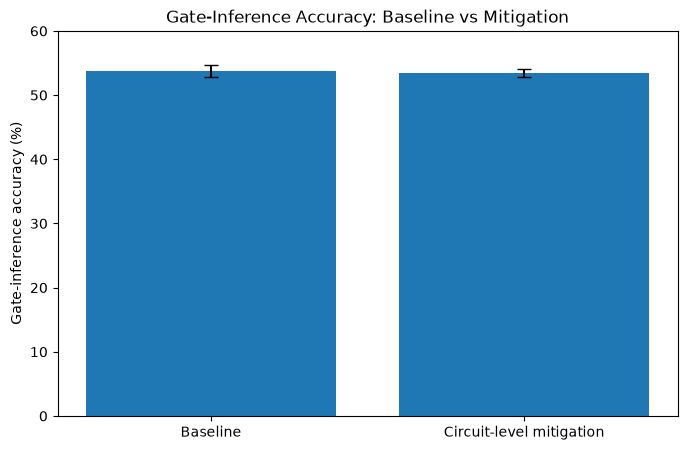

In [97]:
import matplotlib.pyplot as plt
import numpy as np

baseline_accuracy_mean = comparison_df.loc[
    comparison_df["Metric"] == "Gate inference accuracy",
    "Baseline Mean"
].iloc[0] * 100

baseline_accuracy_std = comparison_df.loc[
    comparison_df["Metric"] == "Gate inference accuracy",
    "Baseline Std"
].iloc[0] * 100

mitigation_accuracy_mean = comparison_df.loc[
    comparison_df["Metric"] == "Gate inference accuracy",
    "Mitigation Mean"
].iloc[0] * 100

mitigation_accuracy_std = comparison_df.loc[
    comparison_df["Metric"] == "Gate inference accuracy",
    "Mitigation Std"
].iloc[0] * 100

labels = ["Baseline", "Circuit-level mitigation"]
means = [baseline_accuracy_mean, mitigation_accuracy_mean]
stds = [baseline_accuracy_std, mitigation_accuracy_std]

plt.figure(figsize=(8, 5))
plt.bar(labels, means, yerr=stds, capsize=5)
plt.ylabel("Gate-inference accuracy (%)")
plt.title("Gate-Inference Accuracy: Baseline vs Mitigation")
plt.ylim(0, 60)
plt.show()

### Gate-inference accuracy

The baseline and mitigation means are close to one another, but the mitigation experiment has a lower mean gate-inference accuracy.

The error bars show the run-to-run variation over the 10 independent repetitions.

The measured difference is approximately 0.402 percentage points in favor of a lower classification accuracy for the mitigation experiment.

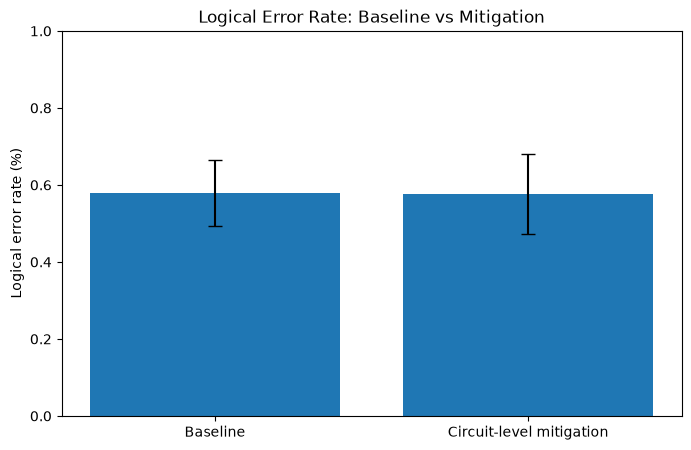

In [99]:
baseline_ler_mean = comparison_df.loc[
    comparison_df["Metric"] == "Logical error rate",
    "Baseline Mean"
].iloc[0] * 100

baseline_ler_std = comparison_df.loc[
    comparison_df["Metric"] == "Logical error rate",
    "Baseline Std"
].iloc[0] * 100

mitigation_ler_mean = comparison_df.loc[
    comparison_df["Metric"] == "Logical error rate",
    "Mitigation Mean"
].iloc[0] * 100

mitigation_ler_std = comparison_df.loc[
    comparison_df["Metric"] == "Logical error rate",
    "Mitigation Std"
].iloc[0] * 100

labels = ["Baseline", "Circuit-level mitigation"]
means = [baseline_ler_mean, mitigation_ler_mean]
stds = [baseline_ler_std, mitigation_ler_std]

plt.figure(figsize=(8, 5))
plt.bar(labels, means, yerr=stds, capsize=5)
plt.ylabel("Logical error rate (%)")
plt.title("Logical Error Rate: Baseline vs Mitigation")
plt.ylim(0, 1)
plt.show()

### Logical error rate

The mean logical error rate is approximately 0.58% for both experiments.

The difference between the baseline and mitigation means is approximately 0.002 percentage points, which is very small relative to the observed run-to-run variation.

This indicates that the circuit-level virtual-error injection did not produce a substantial change in the measured logical error rate in this experiment.

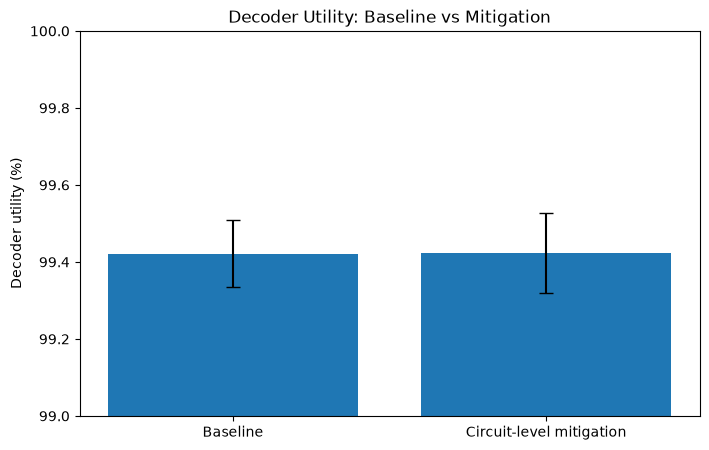

In [100]:
baseline_utility_mean = comparison_df.loc[
    comparison_df["Metric"] == "Decoder utility",
    "Baseline Mean"
].iloc[0] * 100

baseline_utility_std = comparison_df.loc[
    comparison_df["Metric"] == "Decoder utility",
    "Baseline Std"
].iloc[0] * 100

mitigation_utility_mean = comparison_df.loc[
    comparison_df["Metric"] == "Decoder utility",
    "Mitigation Mean"
].iloc[0] * 100

mitigation_utility_std = comparison_df.loc[
    comparison_df["Metric"] == "Decoder utility",
    "Mitigation Std"
].iloc[0] * 100

labels = ["Baseline", "Circuit-level mitigation"]
means = [baseline_utility_mean, mitigation_utility_mean]
stds = [baseline_utility_std, mitigation_utility_std]

plt.figure(figsize=(8, 5))
plt.bar(labels, means, yerr=stds, capsize=5)
plt.ylabel("Decoder utility (%)")
plt.title("Decoder Utility: Baseline vs Mitigation")
plt.ylim(99, 100)
plt.show()

### Decoder utility

Decoder utility remains approximately 99.42% in both experiments.

The difference between the mean baseline and mitigation utility is approximately 0.002 percentage points.

Therefore, within the variability observed across the 10 runs, decoder utility remains approximately unchanged after circuit-level virtual-error injection.

## 27. Final Quantitative Summary

The repeated experiments provide the following comparison between the original circuits and the circuit-level virtual-error mitigation:

| Metric | Baseline | Mitigation | Change |
|---|---:|---:|---:|
| Gate-inference accuracy | 53.810% ± 0.950% | 53.408% ± 0.629% | −0.402 pp |
| Logical error rate | 0.579% ± 0.087% | 0.577% ± 0.103% | −0.002 pp |
| Decoder utility | 99.421% ± 0.087% | 99.423% ± 0.103% | +0.002 pp |

The circuit-level virtual-error experiment therefore produced a small reduction in gate-inference accuracy while maintaining approximately the same decoder performance.

The experiment used an approximately balanced mixture of modified and unmodified shots, with 49.821% ± 0.408% of shots receiving a virtual Pauli error.

## 28. Limitations and Interpretation

The results of this experiment should be interpreted within the scope of the implemented circuit-level simulation.

### 28.1 Scope of the circuit model

The experiment uses the distance-5 unrotated surface-code circuits H_L and S_L from the preceding notebook. The conclusions therefore apply to this specific circuit construction, noise model, decoder, and measurement configuration.

The experiment does not establish that the same effect will occur for other code distances, logical gates, circuit architectures, physical noise models, or decoders.

### 28.2 Scope of the virtual-error mitigation

The virtual Pauli errors are inserted directly into the simulated circuit and are tracked according to the Pauli-frame propagation rules established earlier in the notebook.

This experiment evaluates the effect of this procedure on the available detector data. It should not be interpreted as a complete implementation of a practical decoder-side-channel mitigation protocol.

The experiment provides an empirical test of whether circuit-level virtual-error randomization can modify the information available to a gate-inference classifier while preserving decoder performance.

### 28.3 Interpretation of gate-inference accuracy

The repeated baseline experiment produced a mean gate-inference accuracy of:

53.810% ± 0.950 percentage points

The circuit-level mitigation experiment produced:

53.408% ± 0.629 percentage points

The observed difference is approximately:

−0.402 percentage points

Thus, the mitigation experiment produced a small reduction in the measured classifier accuracy.

However, this difference is modest compared with the run-to-run variability of the repeated experiments. Therefore, the experiment alone does not establish a statistically significant reduction in gate-inference accuracy.

A larger number of repetitions and/or additional statistical testing would be required to make a stronger statistical claim.

### 28.4 Interpretation of decoder performance

The baseline logical error rate was:

0.579% ± 0.087 percentage points

The mitigation logical error rate was:

0.577% ± 0.103 percentage points

The corresponding decoder utilities were:

Baseline: 99.421% ± 0.087 percentage points

Mitigation: 99.423% ± 0.103 percentage points

The difference in decoder utility is approximately:

+0.002 percentage points

Within the scope of this experiment, decoder performance therefore remained approximately unchanged after the circuit-level virtual-error injection.

### 28.5 Balanced virtual-error application

The mitigation experiment produced:

49.821% ± 0.408% modified shots

This is close to the intended 50% modification probability.

The result indicates that the randomized experiment generated approximately equal numbers of modified and unmodified executions, reducing the possibility that an extreme imbalance in the experimental groups explains the observed classifier behavior.

### 28.6 Overall interpretation

Taken together, the experiment shows that, for the implemented surface-code circuits and simulation conditions, circuit-level virtual-error randomization was associated with a small reduction in gate-inference accuracy while maintaining approximately the same decoder utility.

The result should therefore be treated as an experimental observation within the implemented model rather than as evidence of a general or guaranteed security improvement.

## 29. Final Conclusion

This notebook investigated a circuit-level virtual-error mitigation approach for reducing decoder-side gate inference in a distance-5 surface-code simulation.

The motivation follows the decoder-side confidentiality threat model in which spacetime syndrome data can contain gate-dependent fingerprints that may reveal information about the logical computation. The reference work identifies such gate fingerprints as a potential side channel and discusses virtual errors as one possible direction for mitigating the leakage. :contentReference[oaicite:0]{index=0}

The mitigation implemented here uses virtual Pauli errors inserted directly into the quantum circuit. The Pauli-frame propagation rules were used to track the corresponding virtual errors through the Clifford circuit. This follows the principle described by Reichardt, where Pauli corrections can be tracked classically rather than physically applied, with the Pauli frame updated through Clifford/Pauli commutation rules. :contentReference[oaicite:1]{index=1} :contentReference[oaicite:2]{index=2}

A total of 123 possible virtual-error cases were considered, corresponding to 41 data qubits and the three Pauli operators X, Y, and Z. Approximately 50% of the experimental shots received a virtual error.

Across 10 independent baseline runs, the mean results were:

- Gate-inference accuracy: 53.810% ± 0.950 percentage points
- Logical error rate: 0.579% ± 0.087 percentage points
- Decoder utility: 99.421% ± 0.087 percentage points

Across 10 independent circuit-level mitigation runs, the mean results were:

- Gate-inference accuracy: 53.408% ± 0.629 percentage points
- Logical error rate: 0.577% ± 0.103 percentage points
- Decoder utility: 99.423% ± 0.103 percentage points
- Modified shots: 49.821% ± 0.408 percentage points

Relative to the repeated baseline, the observed change in gate-inference accuracy was approximately −0.402 percentage points.

The observed change in decoder utility was approximately +0.002 percentage points, while the logical error rate changed by approximately −0.002 percentage points.

These results indicate that, under the implemented simulation conditions, circuit-level virtual-error injection was associated with a small reduction in gate-inference accuracy while decoder utility remained approximately unchanged.

This experiment is a controlled numerical study rather than a demonstration of a complete security protocol. The result is specific to the implemented surface-code circuits, noise model, virtual-error placement, classifier, decoder, and sampling procedure. The reference work itself notes that the effectiveness of virtual errors and related obfuscation strategies for hiding gate fingerprints requires further research. :contentReference[oaicite:3]{index=3}

Further work should therefore investigate larger numbers of repetitions, alternative virtual-error distributions, other logical operations and circuit constructions, additional inference models, different noise regimes, and ultimately validation on more realistic fault-tolerant architectures or quantum hardware.

## 30. References

[1] S. Shukla, D. E. Browne, and S. Nishio, "Anticipating decoder side-channel attacks in fault-tolerant quantum computers," arXiv:2607.12174, 2026.

[2] B. W. Reichardt, "Error-detection-based quantum fault tolerance against discrete Pauli noise," Ph.D. dissertation, University of California, Berkeley, 2006. Technical Report UCB/EECS-2006-157.

The primary conceptual references for this notebook are Shukla, Browne, and Nishio for decoder-side gate fingerprints and virtual-error mitigation, and Reichardt for Pauli-frame tracking and virtual Pauli corrections.